# Project : Sleep posture monitoring (A3)

### Course: Human Data Analytics 2023-2024
### Group Members: Fairouz Baz Radwan (ID:2071913) & Sofia Pope Trogu (ID:2072117)
#### Last Updated: 11/07/2024

In [1]:
# Set which GPU to use
import os
import tensorflow as tf
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID" 
os.environ["CUDA_VISIBLE_DEVICES"]="2"
physical_devices = tf.config.experimental.list_physical_devices('GPU')
tf.config.experimental.set_memory_growth(physical_devices[0], True)

2025-10-18 12:03:36.132662: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-18 12:03:36.176773: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-18 12:03:37.204106: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1760781817.759689  126532 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1760781817.861173  126532 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are install

IndexError: list index out of range

In [2]:
# Import Libraries
import numpy as np
import pandas as pd
import os
import sys
import time
import math
from collections import Counter
import warnings

# Tensorflow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Input
from tensorflow.keras.layers import Add, Dense, Activation, ZeroPadding2D, BatchNormalization, Flatten, Conv2D, AveragePooling2D, MaxPooling2D, GlobalMaxPooling2D, Dropout, Lambda
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import EarlyStopping
import keras.utils.vis_utils
from importlib import reload
reload(keras.utils.vis_utils)
from keras.utils.vis_utils import plot_model   
import h5py 

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import ndimage
from PIL import Image, ImageOps, ImageDraw, ImageFont

# sklearn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, accuracy_score
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score, silhouette_score
from scipy.optimize import linear_sum_assignment

%matplotlib inline
np.random.seed(123)

ModuleNotFoundError: No module named 'keras.utils.vis_utils'

## Data Load and preprocessing

We used data from the first experiment in the public PmatData dataset.

Information about the dataset:
- Samples are collected using Vista Medical FSA Soft- Flex 2048
- The main data folder contains 13 directories corresponding to 13 subjects. Each folder contains 17 txt files, which correspond to the 17 possible sleeping postures (8 standard and 9 uncommon postures)
- Each file contains multiple recordings of the subject posture in the form of pressure matrices, sampled at 1Hz. Each row is length 2,048 representing the 64x32 pressure mat size. Pressure ratings range from 0 to 1000
- 2-mins (around 120 frames) of data was recorded per subject

Source of dataset: https://physionet.org/content/pmd/1.0.0/

In [3]:
# Path to extract data and save files
path = os.getcwd()

In [4]:
# Table of Subject Information
subj_inf = pd.read_csv(path + '/data/experiment-i/subject-info-i.csv', encoding = 'utf_16', index_col='Subject-Number')
display(subj_inf)

,Age,Height/cm,Weight/kg
Subject-Number,,,
1,19,175,87
2,23,183,85
3,23,183,100
4,24,177,70
5,24,172,66
6,26,169,83
7,27,179,96
8,27,186,63
9,30,174,74


In [5]:
# List of Subjects in Experiment I
subj_list = [file for file in os.listdir(path +'/data/experiment-i/') if os.path.isdir(os.path.join(path +'/data/experiment-i/', file))]
print(f"The subjects in Experiment I are: {subj_list}")

The subjects in Experiment I are: ['S1', 'S10', 'S11', 'S12', 'S13', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']


In [6]:
# Number of Positions for Each Subject
positions_cnt = [file for file in os.listdir(path +'/data/experiment-i/S5/') if os.path.isfile(os.path.join(path +'/data/experiment-i/S5/', file))]
print(f"The number of positions for each subject are: {len(positions_cnt)}")

The number of positions for each subject are: 17


In [7]:
# macro position vector
positions_i = ["placeholder", "supine", "right",
                     "left", "right", "right",
                     "left", "left", "supine",
                     "supine", "supine", "supine",
                     "supine", "right", "left",
                     "supine", "supine", "supine"]

In [8]:
# Use position names to define 3 common positions

def token_position(x):
    return {
        'supine': 0,
        'left': 1,
        'right': 2,
        'left_fetus': 1,
        'right_fetus': 2
    }[x]

In [9]:
# Tokenize the labels
def token_patient(x):
    return {'S1': 0, 'S2': 1, 'S3': 2, 'S4': 3, 'S5': 4,  'S6': 5, 'S7': 6,
                    'S8': 7, 'S9': 8, 'S10': 9, 'S11': 10, 'S12': 11, 'S13':12}[x]

In [10]:
# Specific position vector
positions_ii = ['placeholder', 'supine','right','left','right_30_roll','right_60_roll','left_30_roll','left_60_roll','supine_star','supine_hand_crossed','supine_knees_up','supine_right_knee_up','supine_left_knee_up','right_fetus','left_fetus','supine_30_inclination','supine_45_inclination','supine_60_inclination']

In [11]:
# Inspect one file
test_read = np.loadtxt(path + '/data/experiment-i/S6/1.txt')
test_read.shape # (101, 2048) = (number of samples, number of sensors (32x64))

(107, 2048)

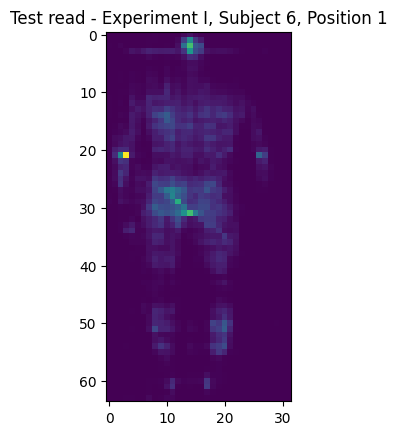

In [12]:
# Example of one sample
plt.title("Test read - Experiment I, Subject 6, Position 1")
plt.imshow(test_read[21,:].reshape(64, 32)) # 22nd sample
plt.show()

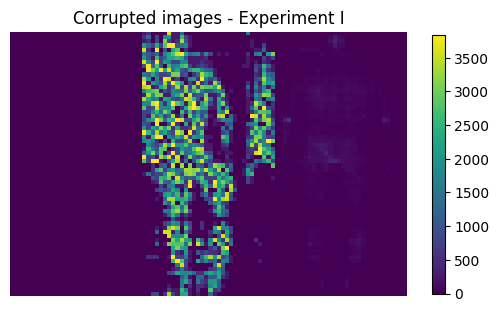

In [13]:
# Show that first three samples are corrupted

# Plot the first three samples
image_0 = test_read[0, :].reshape(64, 32)
image_1 = test_read[1, :].reshape(64, 32)
image_2 = test_read[2, :].reshape(64, 32)

image_concat = np.concatenate((image_0, image_1, image_2), axis=1)

# Show the plot
plt.figure()
plt.imshow(image_concat, cmap='viridis', interpolation='nearest')
plt.title('Corrupted images - Experiment I')
plt.colorbar(shrink=0.7)
plt.axis('off')
plt.show()

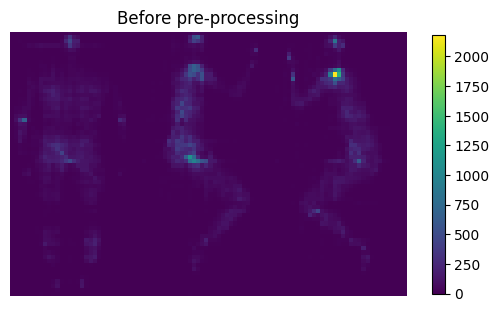

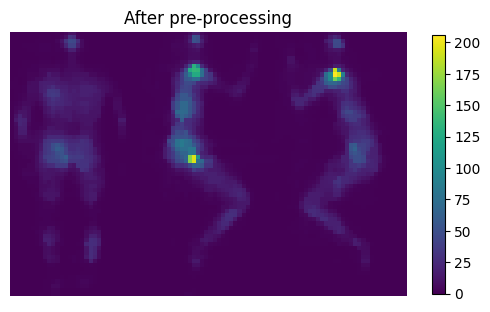

In [14]:
# Demonstrating the effect of pre and post preprocessing for 3 different postures

def preprocess(img):
    median_data = ndimage.median_filter(img, size=(3, 3))
    norm_median_data = np.round(median_data * 255 / 1000).astype(np.uint8)
    return norm_median_data

#getting the first 3 postures of subject 6 
supine= np.loadtxt(path + '/data/experiment-i/S6/1.txt')
left = np.loadtxt(path + '/data/experiment-i/S6/2.txt')
right = np.loadtxt(path + '/data/experiment-i/S6/3.txt')

#getting the 20th image of each posture
image_0 = supine[20, :].reshape(64, 32)
image_1 = left[20, :].reshape(64, 32)
image_2 = right[20, :].reshape(64, 32)

image_concat = np.concatenate((image_0, image_1, image_2), axis=1)

# Show the plot
plt.figure()
plt.imshow(image_concat, cmap='viridis', interpolation='nearest')
plt.title('Before pre-processing')
plt.colorbar(shrink=0.7)
plt.axis('off')
plt.show()


#applying the preprocessing steps on the above images:
image_0_pp = preprocess(image_0)
image_1_pp = preprocess(image_1)
image_2_pp = preprocess(image_2)

image_concat_pp = np.concatenate((image_0_pp, image_1_pp, image_2_pp), axis=1)

# Show the plot
plt.figure()
plt.imshow(image_concat_pp, cmap='viridis', interpolation='nearest')
plt.title('After pre-processing')
plt.colorbar(shrink=0.7)
plt.axis('off')
plt.show()

In [15]:
# Load all the data into a dictionary, where the keys are the subjects and the
# values: images (index 0), position's number (index 1), and specific position's name (index 2)

# Initialize dictionary to store the data
exp_i_data = {}

# Directory structure: /data/experiment-i/subject/position.txt
for _, dirs, _ in os.walk(path + '/data/experiment-i/'):  
    # Loop through each subject
    for dir in dirs:
        subject = dir
        data = None
        labels = None
        # Loop through each position file in the subject's directory
        for _, _, files in os.walk(path + '/data/experiment-i/' + dir):
            for file in files:
                # Posture path
                file_path = path + '/data/experiment-i/' + dir + '/' + file
                with open(file_path, 'r') as f:
                    # We remove first and last 3 corrupted frames - suggestion from the dataset's authors
                    for line in f.read().splitlines()[3:-3]:
                        #reshape each image in the posture file into a 64x32 array
                        raw_data = np.fromstring(line, dtype=float, sep='\t').reshape(1, 64, 32)
                        # apply median filter of 3x3
                        raw_data = ndimage.median_filter(raw_data, size=(1,3,3))

                        # Normalize the data: change range from [0-1000] to [0-255]
                        file_data = np.round(raw_data*255/1000).astype(np.uint8)

                        # Label the data using position number from file name, gives 0,1 or 2
                        file_label = token_position(positions_i[int(file[:-4])])                        
                        file_label = np.array([file_label])

                        # Specific position label (17 micro postures name)
                        position_label = positions_ii[int(file[:-4])]
                        position_label = np.array([position_label])

                        # Tokenize the position index for the 17 micro postures 
                        position_index = int(file[:-4])-1
                        position_index = np.array([position_index])

                        if data is None:
                            data = file_data
                        else:
                            # Concatenate the new data along the first axis
                            data = np.concatenate((data, file_data), axis=0)
                        #labels contain label for the 3 main postures, while position_indices for the 17 micro postures
                        if labels is None:
                            labels = file_label
                            positions = position_label
                            position_indices = position_index
                        else:
                            labels = np.concatenate((labels, file_label), axis=0)
                            positions = np.concatenate((positions, position_label), axis=0)
                            position_indices = np.concatenate((position_indices, position_index), axis=0)
                        
        exp_i_data[subject] = {'data': data, 'labels': labels, 'position_indices': position_indices, 'positions': positions}

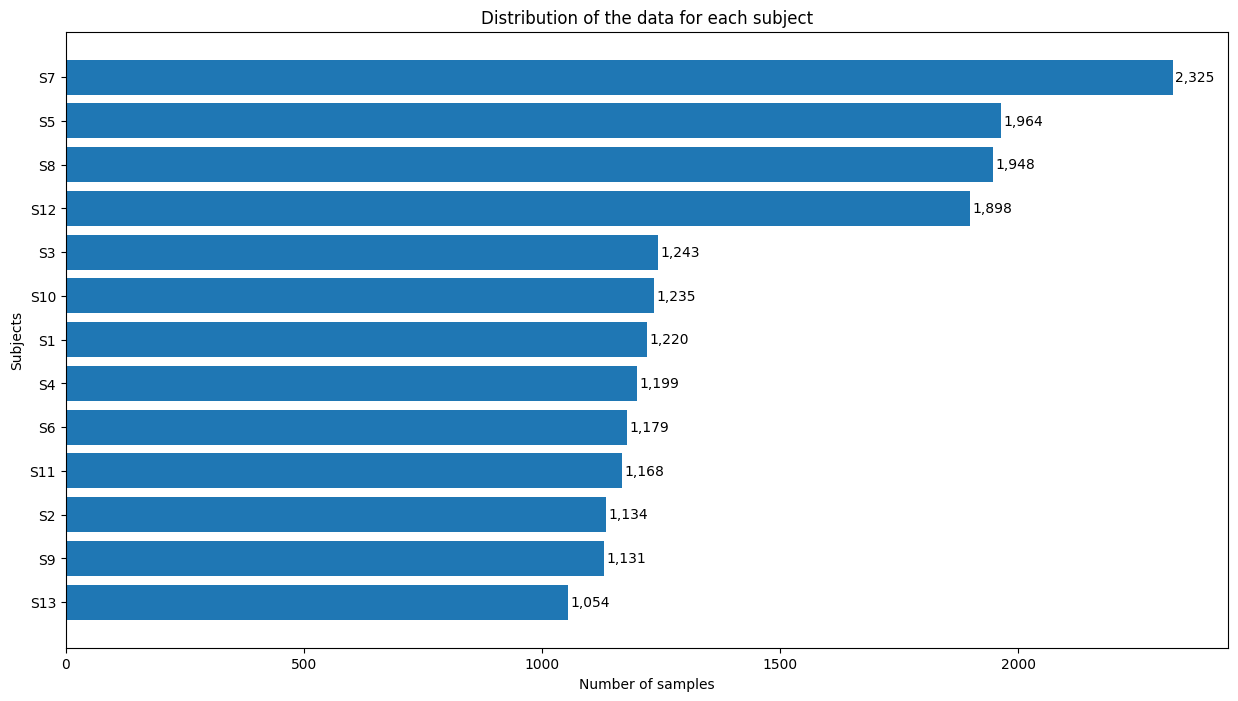

In [16]:
# Distribution of the data for each subjects

data_counts = {}

for subject, data in exp_i_data.items():
    data_counts[subject] = data['data'].shape[0]

sorted_subjects = sorted(data_counts.items(), key=lambda item: item[1])

# Plot the distribution of the data
plt.figure(figsize=(15, 8))
bars = plt.barh([subj for subj, count in sorted_subjects], [count for subj, count in sorted_subjects])

# Add the value at the end of each bar
for bar in bars:
    plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, f'{bar.get_width():,}', va='center', color='black')
plt.xlabel('Number of samples')
plt.ylabel('Subjects')
plt.title('Distribution of the data for each subject')
plt.show()


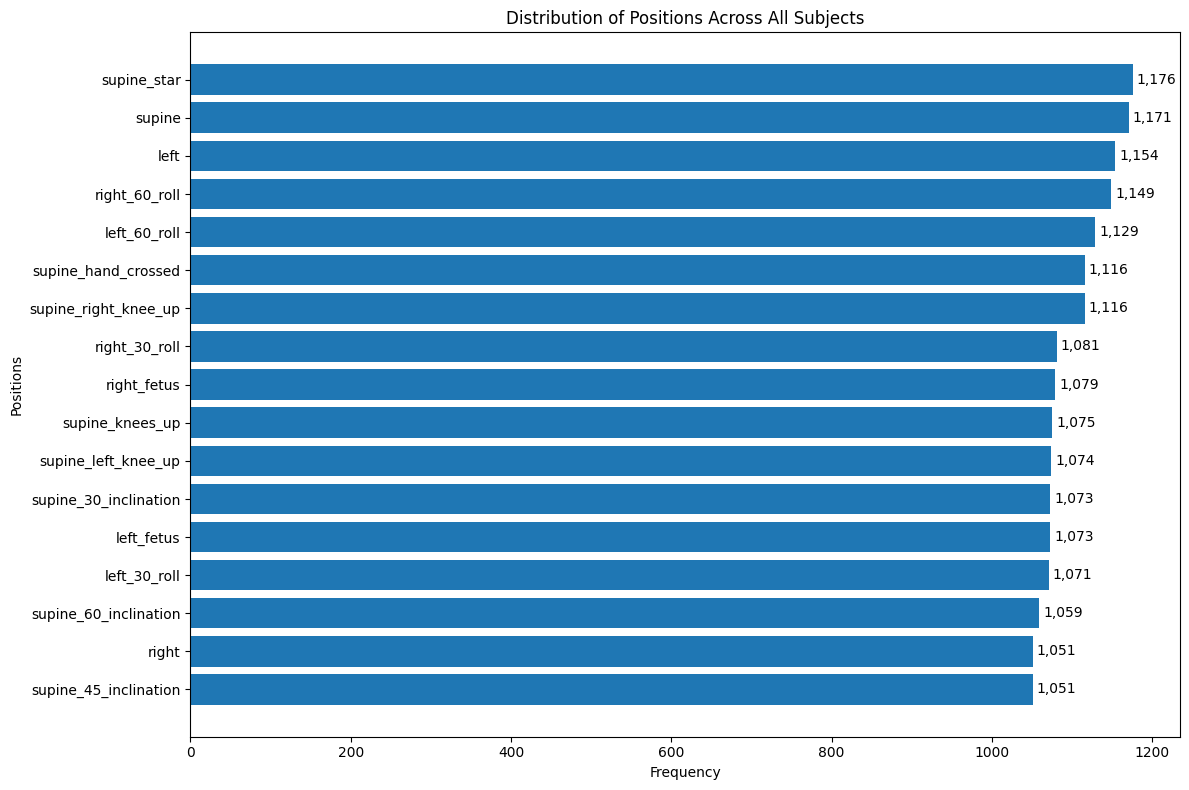

In [17]:
# Show the distribution of the positions across the subjects

position_counts = Counter()

for subject_data in exp_i_data.values():
    position_counts.update(subject_data['positions'])

# Sort positions by count in descending order
sorted_positions_counts = sorted(position_counts.items(), key=lambda item: item[1])
positions, counts = zip(*sorted_positions_counts)

# Plot the distribution of positions
plt.figure(figsize=(12, 8))
bars = plt.barh(positions, counts)

# Add values at the end of each bar
for bar in bars:
    plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, f'{bar.get_width():,}', va='center', color='black')

plt.xlabel('Frequency')
plt.ylabel('Positions')
plt.title('Distribution of Positions Across All Subjects')
plt.tight_layout()
plt.show()



#### Dataset Creation and Train-Test Split

In [18]:
def create_dataset(ylabel):
    X = []
    y = []
    label_s = []
     #storing the whole dataset for all subjects in X with their corresponding subject label and posture labels in label_s and y, respectively
    for subject in subj_list:
        data = exp_i_data[subject]['data']
        position_label = exp_i_data[subject][ylabel]
        subject_token = np.full(len(data), token_patient(subject))

        X.append(data)
        y.append(position_label)
        label_s.append(subject_token)

    # Concatenate all data, labels, and tokens
    X = np.concatenate(X, axis=0)
    y = np.concatenate(y, axis=0)
    label_s = np.concatenate(label_s, axis=0)

    return X, y, label_s

In [19]:
# Task 1: Predict the macro position (supine, left, right), ylabel = 'labels'
# Task 2: Predict the specific position (17 positions), ylabel = 'position_indices'
X, y, label_s = create_dataset('position_indices')
#X, y, label_s = create_dataset('labels')
print(X.shape, y.shape, label_s.shape)

(18698, 64, 32) (18698,) (18698,)


In [20]:
# Train-Test Split

# 70% training set, 20% validation set and 10% test set

# Experiment I
indices = np.arange(len(X))
X_train_val, X_test, y_train_val, y_test, indices_train_val, indices_test, = train_test_split(X, y, indices, test_size=0.1, random_state=123)
X_train, X_val, y_train, y_val, indices_train, indices_val = train_test_split(X_train_val, y_train_val, indices_train_val, test_size=0.2222, random_state=123)

# Split label_s accordingly using indices
label_s_train = label_s[indices_train]
label_s_val = label_s[indices_val]
label_s_test = label_s[indices_test]

# Print number of samples in each set
print(f"Number of samples in training set: {len(X_train)} ({len(X_train)/len(X):.2%})")
print(f"Number of samples in validation set: {len(X_val)} ({len(X_val)/len(X):.2%})")
print(f"Number of samples in test set: {len(X_test)} ({len(X_test)/len(X):.2%})")

Number of samples in training set: 13088 (70.00%)
Number of samples in validation set: 3740 (20.00%)
Number of samples in test set: 1870 (10.00%)


In [21]:
# One-hot encode the labels

num_postures = 17

label_s_train = tf.keras.utils.to_categorical(label_s_train, num_classes=13)
y_train = tf.keras.utils.to_categorical(y_train, num_classes=num_postures)
label_s_val = tf.keras.utils.to_categorical(label_s_val, num_classes=13)
y_val = tf.keras.utils.to_categorical(y_val, num_classes=num_postures)
label_s_test = tf.keras.utils.to_categorical(label_s_test, num_classes=13)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=num_postures)

### Models Definition

In [23]:
# Define the proposed model from paper

# We need to use functional API instead of typical sequential model since model has multiple outputs

# Create instance of model
def create_model(num_postures, regularization=0):

    input = tf.keras.Input(shape=(64, 32, 1), name="img")

    # Conv Block 1
    x = tf.keras.layers.Conv2D(32, (3, 3), strides=(1,1), padding='valid', kernel_regularizer=l2(regularization))(input)
    x = tf.keras.layers.BatchNormalization(axis=-1)(x)
    x = tf.keras.layers.MaxPool2D((3, 3), strides=(2, 2), padding='same')(x)
    x = tf.keras.layers.LeakyReLU(alpha=0.2)(x)
    x = tf.keras.layers.Dropout(0.1)(x)

    # Conv Block 2
    x = tf.keras.layers.Conv2D(64, (3, 3), strides=(1,1), padding='valid', activation=None, kernel_regularizer=l2(regularization))(x)
    x = tf.keras.layers.BatchNormalization(axis=-1)(x)
    x = tf.keras.layers.MaxPool2D((3,3), strides=(2, 2), padding='valid')(x)
    x = tf.keras.layers.LeakyReLU(alpha=0.2)(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    # Conv Block 3
    x = tf.keras.layers.Conv2D(128, (3, 3), strides=(1,1), padding='valid', activation=None, kernel_regularizer=l2(regularization))(x)
    x = tf.keras.layers.BatchNormalization(axis=-1)(x)
    x = tf.keras.layers.LeakyReLU(alpha=0.2)(x)
    x = tf.keras.layers.Dropout(0.3)(x)

    # Conv Block 4
    x = tf.keras.layers.Conv2D(256, (3, 3), strides=(1,1), padding='valid', activation=None, kernel_regularizer=l2(regularization))(x)
    x = tf.keras.layers.BatchNormalization(axis=-1)(x)
    x = tf.keras.layers.LeakyReLU(alpha=0.2)(x)
    x = tf.keras.layers.Dropout(0.4)(x)

    # Flatten Layer
    x = tf.keras.layers.GlobalMaxPool2D()(x)

    # Dense Layer 1
    x = tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=l2(regularization))(x)
    x = tf.keras.layers.Dropout(0.5)(x)

    # Dense Layer 2
    x = tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=l2(regularization))(x)
    x = tf.keras.layers.Dropout(0.5)(x)

    # Two outputs for subject and posture classification
    subject_output = tf.keras.layers.Dense(13, activation='softmax', name="subject_output")(x)
    posture_output = tf.keras.layers.Dense(num_postures, activation='softmax', name="posture_output")(x)

    base_cnn_model = tf.keras.Model(inputs=input, outputs=[subject_output,posture_output], name="base_cnn_model")

    return base_cnn_model
    

    # Input: 64x32x1

    # 4 main blocks of conv-batchnorm plus max pool for 1st 2 blocks
    # 1st block: 62 x 30 x 32 : cov would make (64-3+1)x(32-3+1) = 62 x 30, max pool would make each 62 x 30  --> 31 x 15, 
    # 2nd block: 29 x 13 x 64 of conv-batchnorm-maxpool-leakyrelu
    # 3rd block: 12 x 4 x 128 of conv-batchnorm-leakyrelu
    # 4th block: 10 x 2 x 256 of conv-batchnorm-leakyrelu

    # Two Dense layers of 256 units with dropout of 0.5
    # Two output layers, multinomial logistic regressors for recognition of subjects (M units) and their sleep postures (N units)

    # Loss function: multiclass cross-entropy loss function of subjects and users separately
    # plus combined loss function of both with hyperparameter lambda (from 0 to 1)

    # Conv kernels: 3x3, stride 1, padding valid
    # Max pool: 3x3
    # batch norm
    # Leaky ReLU: alpha 0.2

    # dense layers have dropout of 0.5

    # each conv block was followed by increasing drop of 10%, 20%, 30%, 40%. 
    # L2 reg loss with coefficient of 0.002
    # 2 softmax regressors

In [24]:
# Define medium model with fewer filters per conv layer

def create_medium_model(num_postures, regularization=0):
    input = tf.keras.Input(shape=(64, 32, 1), name="img")

    # Conv Block 1
    x = tf.keras.layers.Conv2D(16, (3, 3), strides=(1,1), padding='valid', kernel_regularizer=l2(regularization))(input)
    x = tf.keras.layers.BatchNormalization(axis=-1)(x)
    x = tf.keras.layers.MaxPool2D((3, 3), strides=(2, 2), padding='same')(x)
    x = tf.keras.layers.LeakyReLU(alpha=0.2)(x)
    x = tf.keras.layers.Dropout(0.1)(x)

    # Conv Block 2
    x = tf.keras.layers.Conv2D(32, (3, 3), strides=(1,1), padding='valid', activation=None, kernel_regularizer=l2(regularization))(x)
    x = tf.keras.layers.BatchNormalization(axis=-1)(x)
    x = tf.keras.layers.MaxPool2D((3,3), strides=(2, 2), padding='valid')(x)
    x = tf.keras.layers.LeakyReLU(alpha=0.2)(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    # Conv Block 3
    x = tf.keras.layers.Conv2D(64, (3, 3), strides=(1,1), padding='valid', activation=None, kernel_regularizer=l2(regularization))(x)
    x = tf.keras.layers.BatchNormalization(axis=-1)(x)
    x = tf.keras.layers.LeakyReLU(alpha=0.2)(x)
    x = tf.keras.layers.Dropout(0.3)(x)

    # Conv Block 4
    x = tf.keras.layers.Conv2D(128, (3, 3), strides=(1,1), padding='valid', activation=None, kernel_regularizer=l2(regularization))(x)
    x = tf.keras.layers.BatchNormalization(axis=-1)(x)
    x = tf.keras.layers.LeakyReLU(alpha=0.2)(x)
    x = tf.keras.layers.Dropout(0.4)(x)

    # Flatten Layer
    x = tf.keras.layers.GlobalMaxPool2D()(x)

    # Dense Layer 1
    x = tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=l2(regularization))(x)
    x = tf.keras.layers.Dropout(0.5)(x)

    # Dense Layer 2
    x = tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=l2(regularization))(x)
    x = tf.keras.layers.Dropout(0.5)(x)

    # Two outputs for subject and posture classification
    subject_output = tf.keras.layers.Dense(13, activation='softmax', name="subject_output")(x)
    posture_output = tf.keras.layers.Dense(num_postures, activation='softmax', name="posture_output")(x)

    model = tf.keras.Model(inputs=input, outputs=[subject_output,posture_output], name="smaller_cnn_model")

    return model

In [25]:
# Define small model with fewer conv blocks

def create_small_model(num_postures, regularization=0):
    input = tf.keras.Input(shape=(64, 32, 1), name="img")

    # Conv Block 1 
    x = tf.keras.layers.Conv2D(16, (3, 3), strides=(1,1), padding='valid', kernel_regularizer=l2(regularization))(input)
    x = tf.keras.layers.BatchNormalization(axis=-1)(x)
    x = tf.keras.layers.MaxPool2D((3, 3), strides=(2, 2), padding='same')(x)
    x = tf.keras.layers.LeakyReLU(alpha=0.2)(x)
    x = tf.keras.layers.Dropout(0.1)(x)

    # Conv Block 2
    x = tf.keras.layers.Conv2D(32, (3, 3), strides=(1,1), padding='valid', activation=None, kernel_regularizer=l2(regularization))(x)
    x = tf.keras.layers.BatchNormalization(axis=-1)(x)
    x = tf.keras.layers.MaxPool2D((3,3), strides=(2, 2), padding='valid')(x)
    x = tf.keras.layers.LeakyReLU(alpha=0.2)(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    # Conv Block 3
    x = tf.keras.layers.Conv2D(64, (3, 3), strides=(1,1), padding='valid', activation=None, kernel_regularizer=l2(regularization))(x)
    x = tf.keras.layers.BatchNormalization(axis=-1)(x)
    x = tf.keras.layers.LeakyReLU(alpha=0.2)(x)
    x = tf.keras.layers.Dropout(0.3)(x)

    # Flatten Layer
    x = tf.keras.layers.GlobalMaxPool2D()(x)

    # Dense Layer 1
    x = tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=l2(regularization))(x)
    x = tf.keras.layers.Dropout(0.5)(x)

    # Dense Layer 2
    x = tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=l2(regularization))(x)
    x = tf.keras.layers.Dropout(0.5)(x)

    # Two outputs for subject and posture classification
    subject_output = tf.keras.layers.Dense(13, activation='softmax', name="subject_output")(x)
    posture_output = tf.keras.layers.Dense(num_postures, activation='softmax', name="posture_output")(x)

    model = tf.keras.Model(inputs=input, outputs=[subject_output,posture_output], name="smaller_cnn_model")

    return model

### Loss Functions for Training

### Notation
- Let $I$ be the input pressure map.
- Let $i$ be the example index.
- Let $\gamma$ and $\delta$ be the user and the posture, respectively
- Let M and N be the number of users and postures, respectively

### Multi-Class Cross Entropy Loss Functions

User Loss:

$$ L_{user} = - \sum_{j=1}^{M} \gamma_{ij} \log P({\gamma_{j}}|I_i)$$


Posture Loss:

$$ L_{posture} = - \sum_{j=1}^{N} \delta_{ij} \log P({\delta_{j}}|I_i)$$

Combined Loss

$$ L = \lambda L_{user} + (1-\lambda)L_{posture} $$

where $\lambda$ is a hyperparameter that enforces the tradeoff between the two objectives - separating users and detecting postures

### Model Training

In [26]:
model_performance = pd.DataFrame(index=['Test Subject Accuracy', 'Test Posture Accuracy', 'Training Time (s)', 'Parameters', 'Model Size (MB)'])

In [28]:
# Parameters
learning_rate = 5e-4 
epochs = 40
batch_size = 32
regularization = 0
lambd_val = 0.5
num_postures = 17
model_name = 'base_cnn_model'

early_stop_callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

# Define the model
if model_name.startswith('base_cnn_'):
        model = create_model(num_postures, regularization)
elif model_name.startswith('medium_cnn_'):
        model = create_medium_model(num_postures, regularization)
elif model_name.startswith('small_cnn_'):
        model = create_small_model(num_postures, regularization)

#we use Adam optimizer
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
#In compile, we assign the subject and posture loss weights which gives us the weighted combined loss 
model.compile(optimizer = optimizer,
        loss= {'subject_output': 'categorical_crossentropy',
                'posture_output': 'categorical_crossentropy'},
        loss_weights = {'subject_output': lambd_val,
                        'posture_output': 1-lambd_val},
        metrics = [tf.keras.metrics.CategoricalAccuracy()]
        )

# Capture the training time
start_time = time.time()

# Train the model
history = model.fit(
                X_train,
                {
                'subject_output': label_s_train, 
                'posture_output': y_train
                 },
                epochs=epochs, 
                batch_size=batch_size, 
                validation_split=0.1, 
                validation_data=(
                        X_val, 
                        {
                        'subject_output': label_s_val, 
                        'posture_output': y_val
                        }
                )
                ,callbacks=[early_stop_callback]
                )

# Capture the end time
end_time = time.time()

# Calculate the elapsed time
training_time = end_time - start_time

# Record the model performance
model_val_subject_acc = history.history['val_subject_output_categorical_accuracy'][-1] #final accuracy in last epoch
model_val_posture_acc = history.history['val_posture_output_categorical_accuracy'][-1]
num_parameters = int(model.count_params())

# Save the model
#model.save(path + f'/models/{model_name}.h5')

# save model size
model_size = os.path.getsize(path + f'/models/{model_name}.h5')
model_size_kb = model_size / 1024
model_size_mb = model_size_kb / 1024

# add new entry to model performance
model_performance[model_name] = [
                                np.round(model_val_subject_acc, 3), 
                                np.round(model_val_posture_acc, 3), 
                                np.round(training_time, 3), 
                                int(num_parameters), 
                                np.round(model_size_mb, 3)]


2024-07-10 12:22:38.504777: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-07-10 12:22:38.505754: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-07-10 12:22:38.506972: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

Epoch 1/40


2024-07-10 12:22:40.449011: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inbase_cnn_model/dropout/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2024-07-10 12:22:40.600153: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:424] Loaded cuDNN version 8907
2024-07-10 12:22:41.714348: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:637] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2024-07-10 12:22:41.717488: I tensorflow/compiler/xla/service/service.cc:169] XLA service 0x70d99d30d600 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-07-10 12:22:41.717506: I tensorflow/compiler/xla/service/service.cc:177]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2024-07-10 12:22:41.720964: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.c

409/409 [==============================] - 7s 6ms/step - loss: 2.4088 - subject_output_loss: 2.5327 - posture_output_loss: 2.2849 - subject_output_categorical_accuracy: 0.1826 - posture_output_categorical_accuracy: 0.2828 - val_loss: 1.8222 - val_subject_output_loss: 2.1194 - val_posture_output_loss: 1.5250 - val_subject_output_categorical_accuracy: 0.3008 - val_posture_output_categorical_accuracy: 0.5960
Epoch 2/40
223/409 [===============>..............] - ETA: 0s - loss: 1.7751 - subject_output_loss: 2.1251 - posture_output_loss: 1.4251 - subject_output_categorical_accuracy: 0.2791 - posture_output_categorical_accuracy: 0.5004

409/409 [==============================] - 2s 5ms/step - loss: 1.6595 - subject_output_loss: 2.0414 - posture_output_loss: 1.2776 - subject_output_categorical_accuracy: 0.2966 - posture_output_categorical_accuracy: 0.5514 - val_loss: 1.3313 - val_subject_output_loss: 1.8380 - val_posture_output_loss: 0.8245 - val_subject_output_categorical_accuracy: 0.3545 - val_posture_output_categorical_accuracy: 0.7690
Epoch 3/40
409/409 [==============================] - 2s 5ms/step - loss: 1.2822 - subject_output_loss: 1.7111 - posture_output_loss: 0.8532 - subject_output_categorical_accuracy: 0.4020 - posture_output_categorical_accuracy: 0.6870 - val_loss: 0.9219 - val_subject_output_loss: 1.3655 - val_posture_output_loss: 0.4783 - val_subject_output_categorical_accuracy: 0.6078 - val_posture_output_categorical_accuracy: 0.8706
Epoch 4/40
409/409 [==============================] - 2s 5ms/step - loss: 1.0179 - subject_output_loss: 1.3813 - posture_output_loss: 0.6545 - subject_output_categorical_a

In [ ]:
model_performance

#model_performance.to_csv(path + '/results/model_performance_df.csv', index=False)

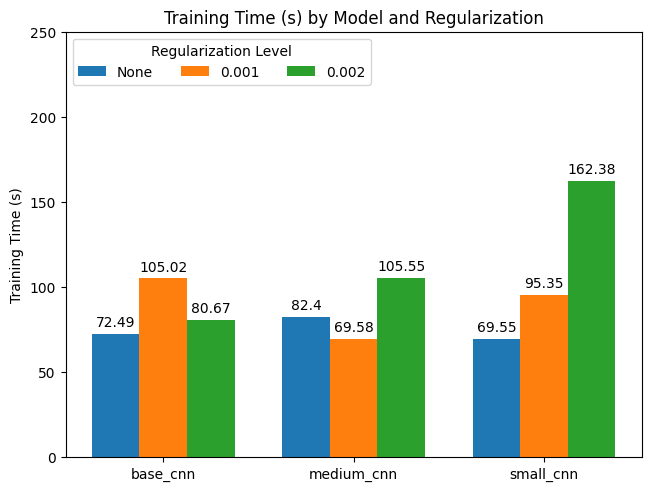

In [37]:
# Plot Training Time Comparison

models = ('base_cnn', 'medium_cnn', 'small_cnn')
training_times = {
    'None': {72.49, 82.40, 69.55},
    '0.001': {69.58, 95.35, 105.02},
    '0.002': {80.67, 105.55, 162.38}
}

x = np.arange(len(models))  # the label locations
width = 0.25  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(layout='constrained')

for regularization, measurement in training_times.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=regularization)
    ax.bar_label(rects, padding=3)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Training Time (s)')
ax.set_title('Training Time (s) by Model and Regularization')
ax.set_xticks(x + width, models)
ax.legend(loc='upper left', ncols=3, title='Regularization Level')
ax.set_ylim(0, 250)

plt.show()


### Loss and Accuracy Plots

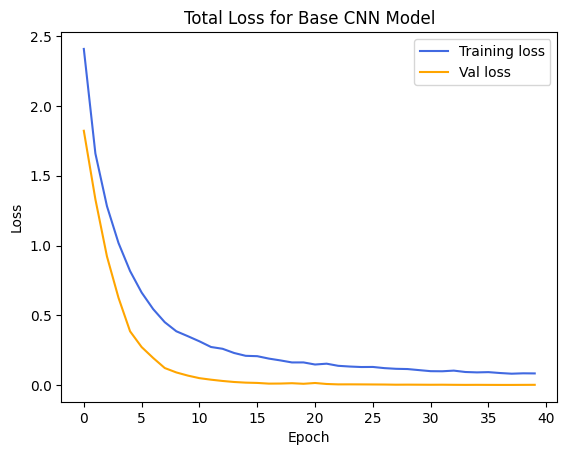

In [35]:
# Plot total loss
plt.figure()
plt.title(f"Total Loss for Base CNN Model")
plt.plot(history.history['loss'], label='Training loss', color = 'royalblue')
plt.plot(history.history['val_loss'], label='Val loss', color = 'orange')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.show()

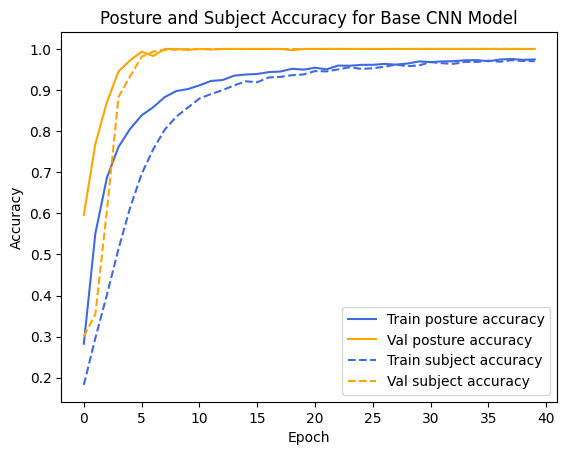

In [36]:
# Plot posture and subject accuracy
plt.figure()
plt.title(f"Posture and Subject Accuracy for Base CNN Model")
plt.plot(history.history['posture_output_categorical_accuracy'], label='Train posture accuracy', color='royalblue')
plt.plot(history.history['val_posture_output_categorical_accuracy'], label='Val posture accuracy', color='orange')
plt.plot(history.history['subject_output_categorical_accuracy'], label='Train subject accuracy', color='royalblue', linestyle='--')
plt.plot(history.history['val_subject_output_categorical_accuracy'], label='Val subject accuracy', color='orange', linestyle='--')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

### Final Model Testing

The following results refer to the Base CNN model without regularization and lambda=0.5, as this model was determined to be the best model.

Model: "base_cnn_model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 img (InputLayer)               [(None, 64, 32, 1)]  0           []                               
                                                                                                  
 conv2d_12 (Conv2D)             (None, 62, 30, 32)   320         ['img[0][0]']                    
                                                                                                  
 batch_normalization_12 (BatchN  (None, 62, 30, 32)  128         ['conv2d_12[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 max_pooling2d_6 (MaxPooling2D)  (None, 31, 15, 32)  0           ['batch_normalizatio

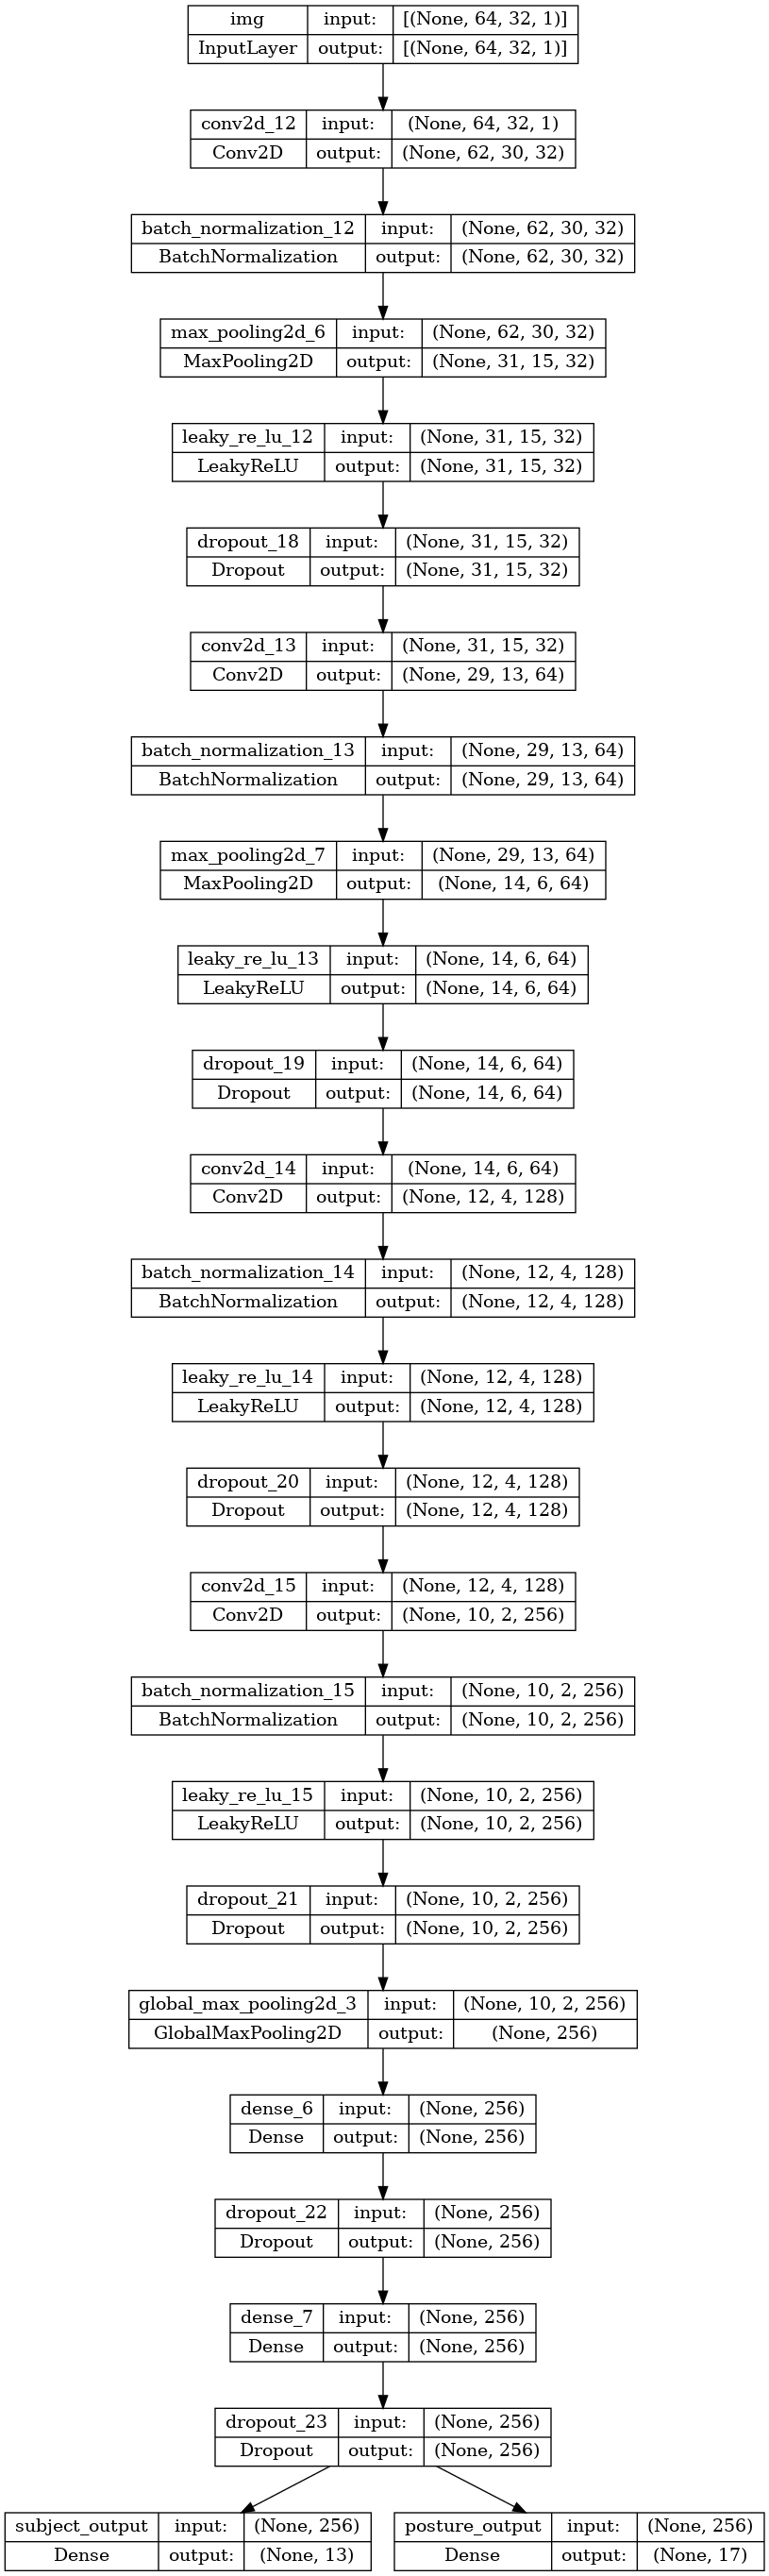

In [49]:
# Summary and plot of the model
model.summary()
plot_model(model, show_shapes=True)

In [128]:
#after training the model, predict on the test set 
print(f'Predict the classification of {X_test.shape[0]} samples')
y_pred_subject, y_pred_posture = model.predict(X_test)

# Determine the predicted classes using argmax
y_pred_posture = np.argmax(y_pred_posture, axis=1)
y_pred_subject = np.argmax(y_pred_subject, axis=1)

Predict the classification of 1870 samples
59/59 [==============================] - 0s 2ms/step


#### Confusion Matrices

In [26]:
# Sort position labels: supine, right, left

positions_ii_sorted = ['supine', 'supine_star', 'supine_hand_crossed', 'supine_knees_up', 'supine_right_knee_up', 'supine_left_knee_up',  
                       'supine_30_inclination', 'supine_45_inclination', 'supine_60_inclination',
                       'right', 'right_30_roll', 'right_60_roll', 'right_fetus',
                       'left', 'left_30_roll', 'left_60_roll', 'left_fetus'
                       ]

# indices of the sorted positions
positions_ii_sorted_indices = [positions_ii.index(position)-1 for position in positions_ii_sorted]

In [130]:
# Extract true labels of posture and subject
y_true = np.argmax(y_test, axis=1)
label_s_true = np.argmax(label_s_test, axis=1)

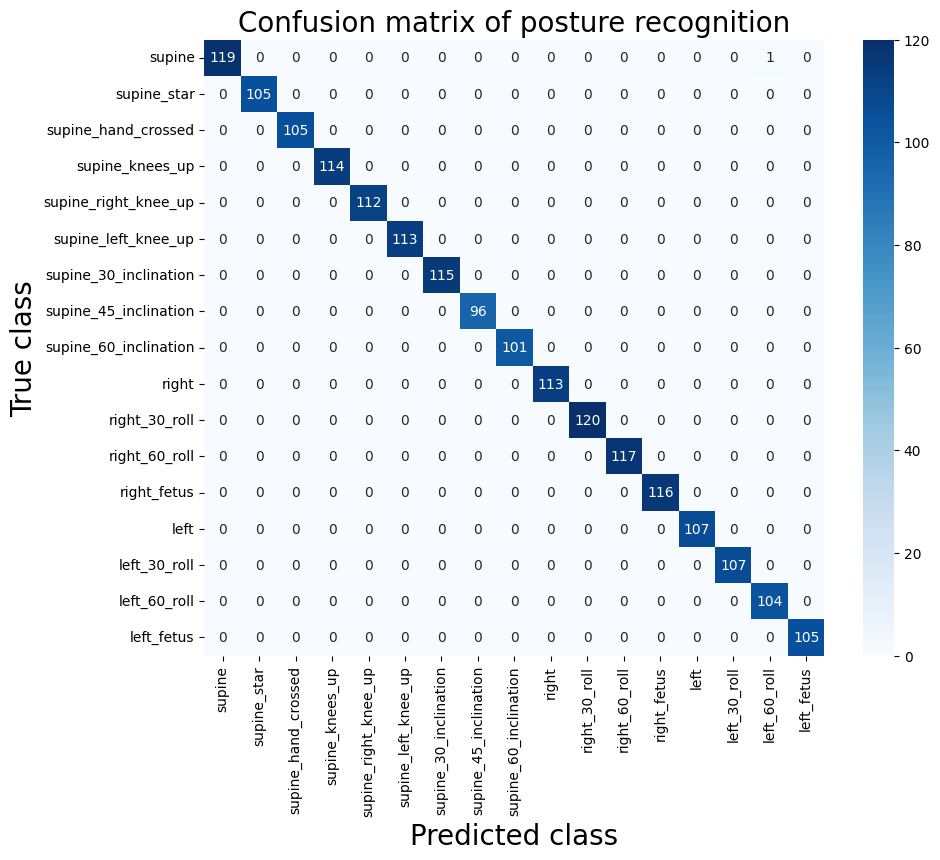

In [131]:
posture_cm = confusion_matrix(y_true=y_true, y_pred=y_pred_posture, labels=positions_ii_sorted_indices)

fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(posture_cm, annot=True, ax = ax, fmt = 'g',cmap='Blues')

# labels, title and ticks
ax.set_xlabel('Predicted class', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(positions_ii_sorted, fontsize = 10)
ax.xaxis.tick_bottom()

ax.set_ylabel('True class', fontsize=20)
ax.yaxis.set_ticklabels(positions_ii_sorted, fontsize = 10)
plt.yticks(rotation=0)

plt.title('Confusion matrix of posture recognition', fontsize=20)

plt.show()
     

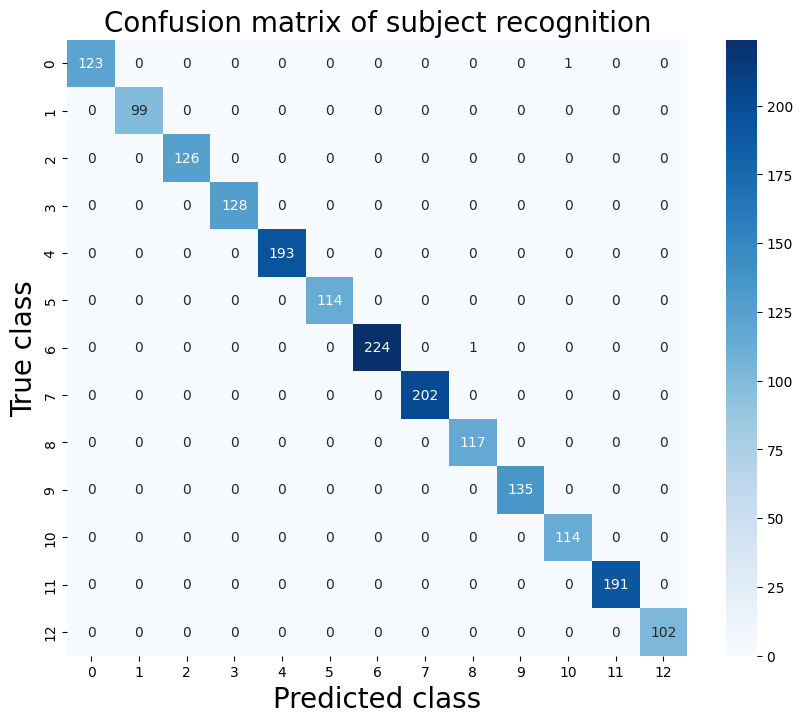

In [132]:
subject_cm = confusion_matrix(y_true=label_s_true, y_pred=y_pred_subject)

fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(subject_cm, annot=True, ax = ax, fmt = 'g',cmap='Blues')

# labels, title and ticks
ax.set_xlabel('Predicted class', fontsize=20)
ax.set_ylabel('True class', fontsize=20)
plt.title('Confusion matrix of subject recognition', fontsize=20)
plt.show()

#### Performance Metrics - Accuracy, Recall, Precision, F1-Score

In [133]:
# Accuracy, Precision, Recall, F1-Score
posture_accuracy = accuracy_score(y_true, y_pred_posture)
subject_accuracy = accuracy_score(label_s_true, y_pred_subject)

posture_precision, posture_recall, posture_fscore, _ = precision_recall_fscore_support(y_true, y_pred_posture)
subject_precision, subject_recall, subject_fscore, _ = precision_recall_fscore_support(label_s_true, y_pred_subject)

# Create a DataFrame to display the results
results = pd.DataFrame(index=['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score'])

# Add the results to the DataFrame
results['Posture'] = [np.round(posture_accuracy,3), 
                      np.round(np.mean(posture_precision),3), 
                      np.round(np.mean(posture_recall),3), 
                      np.round(np.mean(posture_fscore),3)]

results['Subject'] = [np.round(subject_accuracy,3),
                      np.round(np.mean(subject_precision),3),
                      np.round(np.mean(subject_recall),3),
                      np.round(np.mean(subject_fscore),3)]

results

,Posture,Subject
Accuracy (%),0.999,0.999
Precision (%),0.999,0.999
Recall (%),1.000,0.999
F1-Score,0.999,0.999


#### Accuracy for each Macro Position

In [40]:
def macro_pos_acc(posture_cm):
    left_correct = 0
    left_incorrect = 0

    right_correct = 0
    right_incorrect = 0

    supine_correct = 0
    supine_incorrect = 0

    # left
    for i in range(0, 4):
        for j in range(0, 4):
            left_correct += posture_cm[i][j]
        for j in range(4, 17):
            left_incorrect += posture_cm[i][j]

    # right
    for i in range(4, 8):
        for j in range(4, 8):
            right_correct += posture_cm[i][j]
        for j in range(0, 4):
            right_incorrect += posture_cm[i][j]
        for j in range(8, 17):
            right_incorrect += posture_cm[i][j]

    # supine
    for i in range(8, 17):
        for j in range(8, 17):
            supine_correct += posture_cm[i][j]
        for j in range(0, 8):
            supine_incorrect += posture_cm[i][j]

    total_incorrect = left_incorrect + right_incorrect + supine_incorrect

    print(f"Left: Correct: {left_correct}, Incorrect: {left_incorrect}")
    print(f"Right: Correct: {right_correct}, Incorrect: {right_incorrect}")
    print(f"Supine: Correct: {supine_correct}, Incorrect: {supine_incorrect}")
    print(f"Total Incorrect: {total_incorrect}")

    left_accuracy = round(left_correct/(left_correct+left_incorrect), 3)*100
    right_accuracy = round(right_correct/(right_correct+right_incorrect), 3)*100
    supine_accuracy = round(supine_correct/(supine_correct+supine_incorrect), 3)*100

    # print accuracy
    print(f"Left: {left_accuracy}")
    print(f"Right: {right_accuracy}")
    print(f"Supine: {right_accuracy}")

    print("Number of images misclassified: ", total_incorrect)

### K-Fold Cross Validation

In [27]:
# One-hot encode the labels
num_postures = 17

label_s_oh = tf.keras.utils.to_categorical(label_s, num_classes=13)
y_oh = tf.keras.utils.to_categorical(y, num_classes=num_postures)

In [ ]:
# K-Fold Cross Validation on best model to find the best Lambda

initial_learning_rate = 5e-4
epochs = 40
batch_size = 32
regularization = 0
model_name = 'best_model'

lambda_performance = pd.DataFrame(index=['Test Subject Accuracy', 'Test Posture Accuracy', 'Training Time (s)'])

#we stop when the val_loss doesn't change for 3 epochs
early_stop_callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

skf = StratifiedKFold(n_splits=10, shuffle=True)

lambdas = [0.2, 0.5, 0.6, 0.8]

performances = {lambd: [] for lambd in lambdas}
for lambd in lambdas:
    performances[lambd] = []
    for i, (train_index, test_index) in enumerate(skf.split(X, y)):
        print(f"Lambda: {lambd} Fold {i}:")
        model=create_model(num_postures, regularization) # For now, this is the best model
        optimizer = tf.keras.optimizers.Adam(learning_rate=initial_learning_rate)
        model.compile(optimizer = optimizer,
                loss= {'subject_output': 'categorical_crossentropy',
                'posture_output': 'categorical_crossentropy'},
                loss_weights = {'subject_output': lambd,
                        'posture_output': 1-lambd},
                metrics=[tf.keras.metrics.CategoricalAccuracy()])

        start_time = time.time()

        history = model.fit(
            X[train_index], 
            {
                'subject_output': label_s_oh[train_index], 
                'posture_output': y_oh[train_index]
            },
            epochs=epochs, 
            batch_size=batch_size, 
            validation_data=(
                X[test_index], 
                {
                    'subject_output': label_s_oh[test_index], 
                    'posture_output': y_oh[test_index]
                }
            ),
            callbacks=[early_stop_callback]
        )

        end_time = time.time()
        training_time = end_time - start_time
        
        # Record the model performance per fold and lambda
        performances[lambd].append([
                                    history.history["val_subject_output_categorical_accuracy"], 
                                    history.history["val_posture_output_categorical_accuracy"],
                                    training_time
                                    ])


# mean performances for each lamda on subject [0] or posture [1] accuracy
for lambd in lambdas:
    #a list of lists of accuracies over epochs for each fold
    subject_accuracies = [perf[0] for perf in performances[lambd]]
    posture_accuracies = [perf[1] for perf in performances[lambd]]
    training_times = [perf[2] for perf in performances[lambd]]
    
    # Calculate the maximum accuracy for each fold across all epochs
    max_subject_accuracies = [np.max(fold_accuracies) for fold_accuracies in subject_accuracies]
    max_posture_accuracies = [np.max(fold_accuracies) for fold_accuracies in posture_accuracies]
    
    # Calculate the mean of these maximum accuracies over folds
    mean_max_subject_accuracy = np.round(np.mean(max_subject_accuracies), 3)
    mean_max_posture_accuracy = np.round(np.mean(max_posture_accuracies), 3)
    mean_training_time = np.round(np.mean(training_times), 3)
    
    # Append the results to the DataFrame
    lambda_performance[lambd] = [mean_max_subject_accuracy, mean_max_posture_accuracy,mean_training_time]

In [35]:
# K-Fold Cross Validation on best model (lambda = 0.5) 

initial_learning_rate = 5e-4
epochs = 40
batch_size = 32
regularization = 0
lambd = 0.5

model_performance = pd.DataFrame(index=['Subject accuracy (%)',
                                        'Subject precision (%)',
                                        'Subject recall (%)',
                                        'Subject f1-score (%)',
                                        'Posture accuracy (%)',
                                        'Posture precision (%)',
                                        'Posture recall (%)',
                                        'Posture f1-score (%)'
                                        ]
                                )

subject_cm = np.zeros((len(subj_list), len(subj_list)))
posture_cm = np.zeros((num_postures, num_postures))
                                              
early_stop_callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

skf = StratifiedKFold(n_splits=10, random_state = 123, shuffle=True)

for i, (train_index, test_index) in enumerate(skf.split(X, y)):
    print(f"Starting Fold {i}:")
    model=create_model(num_postures, regularization) 
    optimizer = tf.keras.optimizers.Adam(learning_rate=initial_learning_rate)
    model.compile(optimizer = optimizer,
            loss= {'subject_output': 'categorical_crossentropy',
            'posture_output': 'categorical_crossentropy'},
            loss_weights = {'subject_output': lambd,
                    'posture_output': 1-lambd},
            metrics=[tf.keras.metrics.CategoricalAccuracy()])

    history = model.fit(
        X[train_index], 
        {
            'subject_output': label_s_oh[train_index], 
            'posture_output': y_oh[train_index]
        },
        epochs=epochs, 
        batch_size=batch_size, 
        validation_data=(
            X[test_index], 
            {
                'subject_output': label_s_oh[test_index], 
                'posture_output': y_oh[test_index]
            }
        ),
        callbacks=[early_stop_callback]
    )   

    # Get network output for validation set
    y_pred_subject = model.predict(X[test_index])[0]
    y_pred_posture = model.predict(X[test_index])[1]

    # Get estimated class
    y_pred_subject = np.argmax(y_pred_subject, axis =1)
    y_pred_posture = np.argmax(y_pred_posture, axis =1)

    # Get true y
    y_true_subject = label_s[test_index]
    y_true_posture = y[test_index]
    
    # Compute subject and posture confusion matrix
    subject_cm = np.add(subject_cm, 
                        confusion_matrix(y_true=y_true_subject,
                                         y_pred=y_pred_subject
                                        )
                        )
    posture_cm = np.add(posture_cm, 
                        confusion_matrix(y_true=y_true_posture,
                                         y_pred=y_pred_posture,
                                         labels=positions_ii_sorted_indices
                                        )
                        )   

    # Evaluate precision, recall and fscore on this fold
    subject_precision, subject_recall, subject_fscore, _= precision_recall_fscore_support(y_true_subject, y_pred_subject)
    posture_precision, posture_recall, posture_fscore, _= precision_recall_fscore_support(y_true_posture, y_pred_posture)

    # Evaluate accuracy on this fold
    subject_accuracy = accuracy_score(y_true_subject, y_pred_subject)
    posture_accuracy = accuracy_score(y_true_posture, y_pred_posture)
  

    # Record the model performance per fold 
    model_performance[i] = [subject_accuracy*100,
                            np.mean(subject_precision)*100,
                            np.mean(subject_recall)*100,
                            np.mean(subject_fscore)*100,
                            posture_accuracy*100,
                            np.mean(posture_precision)*100,
                            np.mean(posture_recall)*100,
                            np.mean(posture_fscore)*100
                            ]      

Starting Fold 0:
Epoch 1/40


2024-07-10 16:35:01.870365: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inbase_cnn_model/dropout_18/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


526/526 [==============================] - 5s 6ms/step - loss: 2.2726 - subject_output_loss: 2.4317 - posture_output_loss: 2.1135 - subject_output_categorical_accuracy: 0.2060 - posture_output_categorical_accuracy: 0.3227 - val_loss: 1.6588 - val_subject_output_loss: 2.0540 - val_posture_output_loss: 1.2636 - val_subject_output_categorical_accuracy: 0.3107 - val_posture_output_categorical_accuracy: 0.6797
Epoch 2/40
321/526 [=================>............] - ETA: 1s - loss: 1.6014 - subject_output_loss: 1.9842 - posture_output_loss: 1.2187 - subject_output_categorical_accuracy: 0.3196 - posture_output_categorical_accuracy: 0.5681

526/526 [==============================] - 3s 6ms/step - loss: 1.5079 - subject_output_loss: 1.9064 - posture_output_loss: 1.1094 - subject_output_categorical_accuracy: 0.3437 - posture_output_categorical_accuracy: 0.6052 - val_loss: 1.0320 - val_subject_output_loss: 1.4234 - val_posture_output_loss: 0.6405 - val_subject_output_categorical_accuracy: 0.6412 - val_posture_output_categorical_accuracy: 0.8925
Epoch 3/40
526/526 [==============================] - 3s 7ms/step - loss: 1.0995 - subject_output_loss: 1.4690 - posture_output_loss: 0.7300 - subject_output_categorical_accuracy: 0.4881 - posture_output_categorical_accuracy: 0.7338 - val_loss: 0.6272 - val_subject_output_loss: 0.9115 - val_posture_output_loss: 0.3429 - val_subject_output_categorical_accuracy: 0.8626 - val_posture_output_categorical_accuracy: 0.9171
Epoch 4/40
526/526 [==============================] - 3s 6ms/step - loss: 0.8164 - subject_output_loss: 1.0736 - posture_output_loss: 0.5591 - subject_output_categorical_a

2024-07-10 16:37:08.107321: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inbase_cnn_model/dropout_24/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


...

526/526 [==============================] - 6s 6ms/step - loss: 2.2147 - subject_output_loss: 2.3966 - posture_output_loss: 2.0327 - subject_output_categorical_accuracy: 0.2157 - posture_output_categorical_accuracy: 0.3555 - val_loss: 1.5070 - val_subject_output_loss: 1.8618 - val_posture_output_loss: 1.1521 - val_subject_output_categorical_accuracy: 0.4027 - val_posture_output_categorical_accuracy: 0.7155
Epoch 2/40
526/526 [==============================] - 3s 5ms/step - loss: 1.4604 - subject_output_loss: 1.8901 - posture_output_loss: 1.0307 - subject_output_categorical_accuracy: 0.3466 - posture_output_categorical_accuracy: 0.6303 - val_loss: 1.0058 - val_subject_output_loss: 1.4302 - val_posture_output_loss: 0.5814 - val_subject_output_categorical_accuracy: 0.6267 - val_posture_output_categorical_accuracy: 0.8791
Epoch 3/40
526/526 [==============================] - 3s 5ms/step - loss: 1.1019 - subject_output_loss: 1.4890 - posture_output_loss: 0.7147 - subject_output_categorical_a

2024-07-10 16:48:31.983913: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inbase_cnn_model/dropout_66/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


526/526 [==============================] - 6s 6ms/step - loss: 2.2424 - subject_output_loss: 2.4339 - posture_output_loss: 2.0509 - subject_output_categorical_accuracy: 0.1998 - posture_output_categorical_accuracy: 0.3420 - val_loss: 1.5795 - val_subject_output_loss: 1.9832 - val_posture_output_loss: 1.1759 - val_subject_output_categorical_accuracy: 0.3237 - val_posture_output_categorical_accuracy: 0.7459
Epoch 2/40
526/526 [==============================] - 3s 6ms/step - loss: 1.4844 - subject_output_loss: 1.9228 - posture_output_loss: 1.0459 - subject_output_categorical_accuracy: 0.3378 - posture_output_categorical_accuracy: 0.6275 - val_loss: 1.0877 - val_subject_output_loss: 1.5211 - val_posture_output_loss: 0.6543 - val_subject_output_categorical_accuracy: 0.5843 - val_posture_output_categorical_accuracy: 0.8347
Epoch 3/40
526/526 [==============================] - 3s 5ms/step - loss: 1.1370 - subject_output_loss: 1.5205 - posture_output_loss: 0.7536 - subject_output_categorical_a

2024-07-10 16:50:26.059068: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inbase_cnn_model/dropout_72/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


526/526 [==============================] - 6s 6ms/step - loss: 2.2850 - subject_output_loss: 2.4970 - posture_output_loss: 2.0731 - subject_output_categorical_accuracy: 0.1891 - posture_output_categorical_accuracy: 0.3344 - val_loss: 1.6541 - val_subject_output_loss: 2.0505 - val_posture_output_loss: 1.2577 - val_subject_output_categorical_accuracy: 0.3044 - val_posture_output_categorical_accuracy: 0.7389
Epoch 2/40
526/526 [==============================] - 3s 6ms/step - loss: 1.4534 - subject_output_loss: 1.9090 - posture_output_loss: 0.9978 - subject_output_categorical_accuracy: 0.3481 - posture_output_categorical_accuracy: 0.6458 - val_loss: 1.1308 - val_subject_output_loss: 1.7050 - val_posture_output_loss: 0.5566 - val_subject_output_categorical_accuracy: 0.3959 - val_posture_output_categorical_accuracy: 0.8625
Epoch 3/40
526/526 [==============================] - 3s 6ms/step - loss: 1.0581 - subject_output_loss: 1.4261 - posture_output_loss: 0.6900 - subject_output_categorical_a

In [42]:
# Average performance across folds
model_performance.mean(axis=1)

Subject accuracy (%)     99.957216
Subject precision (%)    99.951919
Subject recall (%)       99.963177
Subject f1-score (%)     99.957334
Posture accuracy (%)     99.951869
Posture precision (%)    99.951689
Posture recall (%)       99.952337
Posture f1-score (%)     99.951615
dtype: float64

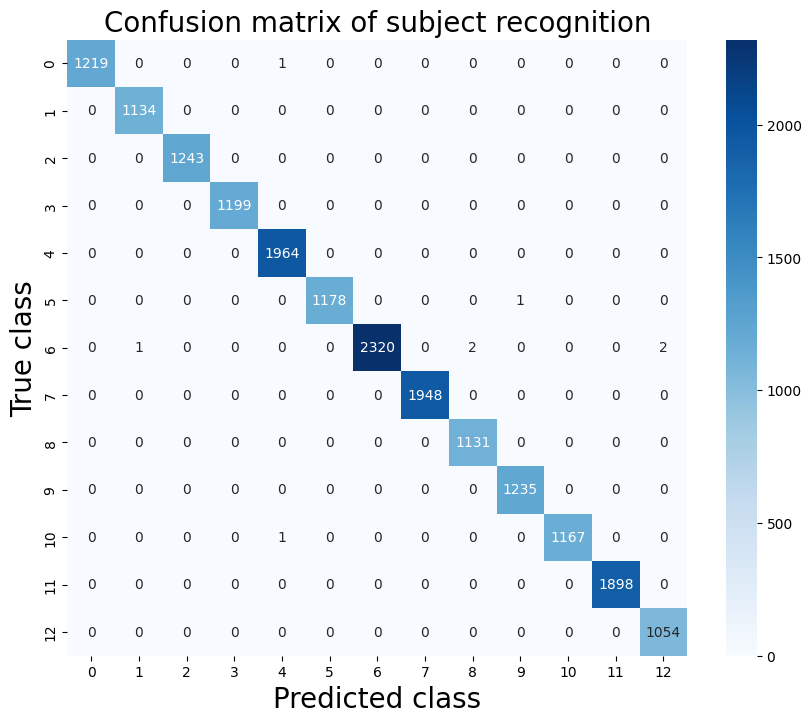

In [37]:
# Plot Subject Confusion Matrix across all the folds

fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(subject_cm, annot=True, ax = ax, fmt = 'g',cmap='Blues')

# labels, title and ticks
ax.set_xlabel('Predicted class', fontsize=20)
ax.set_ylabel('True class', fontsize=20)
plt.title('Confusion matrix of subject recognition', fontsize=20)
plt.show()

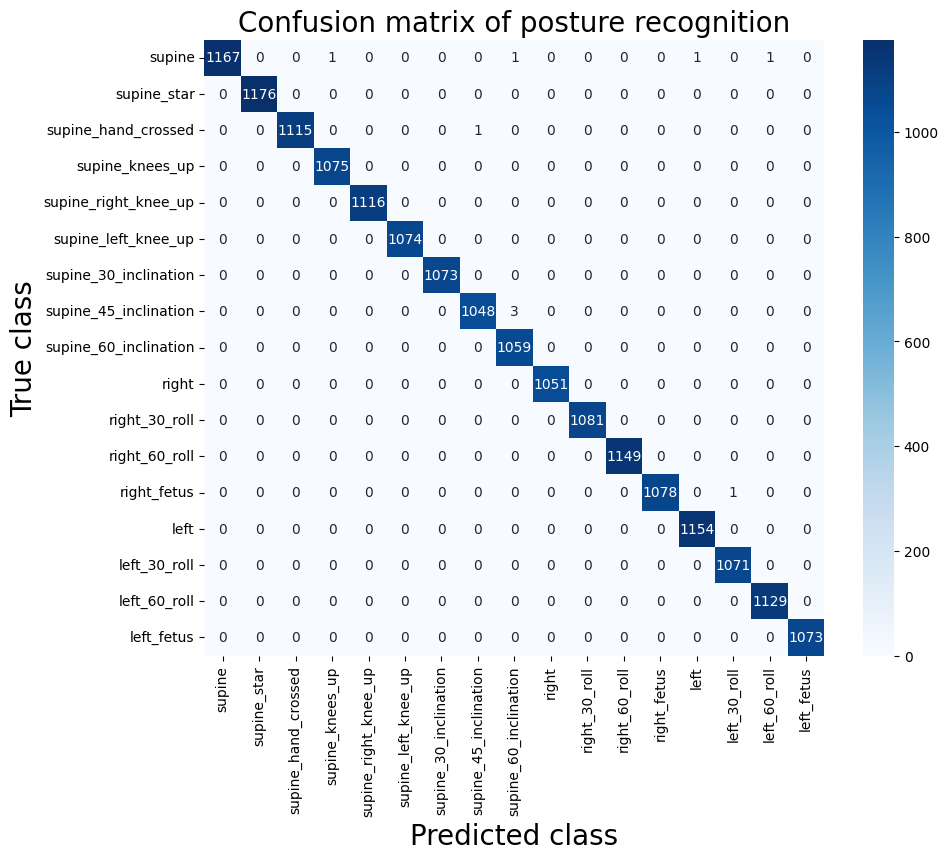

In [38]:
# Plot Posture Confusion Matrix across all the folds

fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(posture_cm, annot=True, ax = ax, fmt = 'g',cmap='Blues')

# labels, title and ticks
ax.set_xlabel('Predicted class', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(positions_ii_sorted, fontsize = 10)
ax.xaxis.tick_bottom()

ax.set_ylabel('True class', fontsize=20)
ax.yaxis.set_ticklabels(positions_ii_sorted, fontsize = 10)
plt.yticks(rotation=0)

plt.title('Confusion matrix of posture recognition', fontsize=20)

plt.show()
     

In [41]:
# Prediction of Main Postures

macro_pos_acc(posture_cm)

Left: Correct: 4534.0, Incorrect: 4.0
Right: Correct: 4311.0, Incorrect: 3.0
Supine: Correct: 9846.0, Incorrect: 0.0
Total Incorrect: 7.0
Left: 99.9
Right: 99.9
Supine: 99.9
Number of images misclassified:  7.0


## LOSO - Leave one Subject out

In [38]:
# Ran LOSO with different lambda values: 0, 0.1, 0.2, and 0.3 for posture recognition 

lambd_val = 0.3

initial_learning_rate = 5e-4
epochs = 40
batch_size = 32
regularization = 0
num_postures = 17

subject_performance = pd.DataFrame(index=['Test Posture Accuracy', 'Training Time (s)'])

early_stop_callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

performances = {subject: [] for subject in range(13)}

for subject in range(13):

    print(f'Running the LOSO model with S{subject+1} removed')
    performances[subject] = []

    # find indices from label_s that correspond with subject index
    subj_indx = np.where(label_s==subject)[0]

    # set test to X and y with those indices
    X_test = X[subj_indx]
    y_test = y[subj_indx]
    label_s_test = label_s[subj_indx]

    # set train to X and y not in those indices

    # Find the indices that are not in subj_indx
    train_indx = np.setdiff1d(np.arange(X.shape[0]), subj_indx)

    # Extract the training set using train_indx
    X_train = X[train_indx]
    y_train = y[train_indx]
    label_s_train = label_s[train_indx]

    label_s_test_oh = tf.keras.utils.to_categorical(label_s_test, num_classes=13)
    y_test_oh = tf.keras.utils.to_categorical(y_test, num_classes=num_postures)
    label_s_train_oh = tf.keras.utils.to_categorical(label_s_train, num_classes=13)
    y_train_oh = tf.keras.utils.to_categorical(y_train, num_classes=num_postures)

    model=create_model(num_postures, regularization) 
    optimizer = tf.keras.optimizers.Adam(learning_rate=initial_learning_rate)
    model.compile(optimizer = optimizer,
            loss= {'subject_output': 'categorical_crossentropy',
                'posture_output': 'categorical_crossentropy'},
            loss_weights = {'subject_output': lambd_val,
                        'posture_output': 1-lambd_val},
            metrics=[tf.keras.metrics.CategoricalAccuracy()])

    start_time = time.time()

    history = model.fit(
        X_train, 
        {
            'subject_output': label_s_train_oh, 
            'posture_output': y_train_oh
        },
        epochs=epochs, 
        batch_size=batch_size, 
        validation_data=(
            X_test, 
            {
                'subject_output': label_s_test_oh, 
                'posture_output': y_test_oh
            }
        ),
        callbacks=[early_stop_callback]
    )

    end_time = time.time()
    training_time = end_time - start_time
    
    # Record the model performance per fold and lambda
    performances[subject].append([
                                history.history["val_posture_output_categorical_accuracy"],
                                training_time
                                ])

Running the LOSO model with S1 removed
Epoch 1/40


2024-07-07 19:11:09.282144: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inbase_cnn_model/dropout_234/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


547/547 [==============================] - 10s 11ms/step - loss: 2.0138 - subject_output_loss: 2.5847 - posture_output_loss: 1.7692 - subject_output_categorical_accuracy: 0.1669 - posture_output_categorical_accuracy: 0.4220 - val_loss: 2.3949 - val_subject_output_loss: 5.4659 - val_posture_output_loss: 1.0787 - val_subject_output_categorical_accuracy: 0.0000e+00 - val_posture_output_categorical_accuracy: 0.6402
Epoch 2/40
547/547 [==============================] - 3s 6ms/step - loss: 1.1127 - subject_output_loss: 2.1809 - posture_output_loss: 0.6549 - subject_output_categorical_accuracy: 0.2680 - posture_output_categorical_accuracy: 0.7644 - val_loss: 2.3546 - val_subject_output_loss: 6.5743 - val_posture_output_loss: 0.5462 - val_subject_output_categorical_accuracy: 0.0000e+00 - val_posture_output_categorical_accuracy: 0.7631
Epoch 3/40
547/547 [==============================] - 6s 11ms/step - loss: 0.7922 - subject_output_loss: 1.8456 - posture_output_loss: 0.3408 - subject_output_ca

2024-07-07 19:11:52.848320: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inbase_cnn_model/dropout_240/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


549/549 [==============================] - 10s 9ms/step - loss: 2.0028 - subject_output_loss: 2.5748 - posture_output_loss: 1.7577 - subject_output_categorical_accuracy: 0.1672 - posture_output_categorical_accuracy: 0.4311 - val_loss: 2.4164 - val_subject_output_loss: 5.2201 - val_posture_output_loss: 1.2149 - val_subject_output_categorical_accuracy: 0.0000e+00 - val_posture_output_categorical_accuracy: 0.6041
Epoch 2/40
549/549 [==============================] - 6s 10ms/step - loss: 1.1039 - subject_output_loss: 2.1510 - posture_output_loss: 0.6552 - subject_output_categorical_accuracy: 0.2756 - posture_output_categorical_accuracy: 0.7644 - val_loss: 2.7440 - val_subject_output_loss: 6.8656 - val_posture_output_loss: 0.9776 - val_subject_output_categorical_accuracy: 0.0000e+00 - val_posture_output_categorical_accuracy: 0.5873
Epoch 3/40
549/549 [==============================] - 3s 6ms/step - loss: 0.7903 - subject_output_loss: 1.8064 - posture_output_loss: 0.3548 - subject_output_cat

...

548/548 [==============================] - 10s 9ms/step - loss: 1.9790 - subject_output_loss: 2.5383 - posture_output_loss: 1.7393 - subject_output_categorical_accuracy: 0.1778 - posture_output_categorical_accuracy: 0.4355 - val_loss: 2.1022 - val_subject_output_loss: 5.3012 - val_posture_output_loss: 0.7313 - val_subject_output_categorical_accuracy: 0.0000e+00 - val_posture_output_categorical_accuracy: 0.7500
Epoch 2/40
548/548 [==============================] - 6s 10ms/step - loss: 1.1035 - subject_output_loss: 2.1042 - posture_output_loss: 0.6747 - subject_output_categorical_accuracy: 0.2869 - posture_output_categorical_accuracy: 0.7527 - val_loss: 2.3578 - val_subject_output_loss: 6.7932 - val_posture_output_loss: 0.4569 - val_subject_output_categorical_accuracy: 0.0000e+00 - val_posture_output_categorical_accuracy: 0.8262
Epoch 3/40
548/548 [==============================] - 6s 12ms/step - loss: 0.7891 - subject_output_loss: 1.7734 - posture_output_loss: 0.3673 - subject_output_ca

2024-07-07 19:16:34.021627: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inbase_cnn_model/dropout_300/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


525/525 [==============================] - 10s 10ms/step - loss: 2.0320 - subject_output_loss: 2.6004 - posture_output_loss: 1.7883 - subject_output_categorical_accuracy: 0.1685 - posture_output_categorical_accuracy: 0.4173 - val_loss: 2.1805 - val_subject_output_loss: 5.2267 - val_posture_output_loss: 0.8750 - val_subject_output_categorical_accuracy: 0.0000e+00 - val_posture_output_categorical_accuracy: 0.7597
Epoch 2/40
525/525 [==============================] - 5s 10ms/step - loss: 1.1161 - subject_output_loss: 2.1446 - posture_output_loss: 0.6752 - subject_output_categorical_accuracy: 0.2775 - posture_output_categorical_accuracy: 0.7547 - val_loss: 2.3746 - val_subject_output_loss: 6.6977 - val_posture_output_loss: 0.5219 - val_subject_output_categorical_accuracy: 0.0000e+00 - val_posture_output_categorical_accuracy: 0.8261
Epoch 3/40
525/525 [==============================] - 4s 7ms/step - loss: 0.8157 - subject_output_loss: 1.8098 - posture_output_loss: 0.3897 - subject_output_ca

2024-07-07 19:16:58.201799: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inbase_cnn_model/dropout_306/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


552/552 [==============================] - 10s 10ms/step - loss: 2.0158 - subject_output_loss: 2.6336 - posture_output_loss: 1.7510 - subject_output_categorical_accuracy: 0.1588 - posture_output_categorical_accuracy: 0.4297 - val_loss: 2.5426 - val_subject_output_loss: 5.4591 - val_posture_output_loss: 1.2927 - val_subject_output_categorical_accuracy: 0.0000e+00 - val_posture_output_categorical_accuracy: 0.6157
Epoch 2/40
552/552 [==============================] - 6s 12ms/step - loss: 1.0998 - subject_output_loss: 2.2049 - posture_output_loss: 0.6262 - subject_output_categorical_accuracy: 0.2573 - posture_output_categorical_accuracy: 0.7744 - val_loss: 2.5274 - val_subject_output_loss: 6.7275 - val_posture_output_loss: 0.7274 - val_subject_output_categorical_accuracy: 0.0000e+00 - val_posture_output_categorical_accuracy: 0.6964
Epoch 3/40
552/552 [==============================] - 7s 12ms/step - loss: 0.8045 - subject_output_loss: 1.8480 - posture_output_loss: 0.3574 - subject_output_c

In [42]:
subject_performance = pd.DataFrame(index=['Final Accuracy', 'Training Time (s)'])
for k, v in performances.items():
    # shape of performance: {... : [[[posture acc over epochs],time]]}
    final_accuracy = v[0][0][-1]
    training_time = v[0][-1]

    subject_performance[k] = [final_accuracy, training_time]

In [43]:
subject_performance_t= subject_performance.T

In [44]:
subject_performance_t

,Final Accuracy,Training Time (s)
0,0.790984,43.143076
1,0.802469,24.927352
2,0.757844,23.754027
3,0.939116,21.122473
4,0.874745,28.043066
5,0.726039,28.659959
6,0.952688,42.929435
7,0.745380,30.132700
8,0.942529,28.047731
9,0.998381,24.745419


In [45]:
np.mean(subject_performance_t['Final Accuracy'])

0.8637167857243464

In [ ]:
# Average subject test accuracy 
# 83.6 % with lambda 0
# 85 % with lambda 0.1
# 84.6% with lambda 0.2
# 86.4 % with lambda 0.3 

## K-Means Clustering and Dimensionality reduction

In [ ]:
# Create dataset with macro labels
X, y, label_s = create_dataset('labels')
print(X.shape, y.shape, label_s.shape)

In [18]:
# Initiate encoding model

trained_model_path = path + '/models/base_cnn_3pos_model.h5'
model = tf.keras.models.load_model(trained_model_path)

# Extract the part of the model up to the GlobalMaxPool2D layer - Feature Encoding Layer
encoding_model = tf.keras.Model(inputs=model.input, outputs=model.get_layer('global_max_pooling2d').output)

encoding_model.summary()

# Save the model
#encoding_model.save(path + f'/models/encoding_model.h5')

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 img (InputLayer)            [(None, 64, 32, 1)]       0         
                                                                 
 conv2d (Conv2D)             (None, 62, 30, 32)        320       
                                                                 
 batch_normalization (BatchN  (None, 62, 30, 32)       128       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 31, 15, 32)       0         
 )                                                               
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 31, 15, 32)        0         
                                                                 
 dropout (Dropout)           (None, 31, 15, 32)        0     

2024-07-11 11:53:42.132428: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-07-11 11:53:42.132715: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-07-11 11:53:42.132945: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

In [19]:
# Produce Encodings

encodings = encoding_model.predict(X)

print('Shape of Encodings:', encodings.shape)

2024-07-11 11:53:43.137027: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:424] Loaded cuDNN version 8907


585/585 [==============================] - 2s 1ms/step
Shape of Encodings: (18698, 256)


In [20]:
# Balance Random Sample of Examples according to class distribution

# Assuming y contains the labels for your dataset
class_0_idx = np.where(y == 0)[0]
class_1_idx = np.where(y == 1)[0]
class_2_idx = np.where(y == 2)[0]

# Calculate the number of samples for each class based on a total desired sample size
total_samples = 1500
class_0_proportion = len(class_0_idx) / len(y)
class_1_proportion = len(class_1_idx) / len(y)
class_2_proportion = len(class_2_idx) / len(y)

class_0_samples = int(total_samples * class_0_proportion)
class_1_samples = int(total_samples * class_1_proportion)
class_2_samples = int(total_samples * class_2_proportion)

# Adjust the number of samples to ensure the total is exactly 200
remaining_samples = total_samples - (class_0_samples + class_1_samples + class_2_samples)
if remaining_samples > 0:
    class_0_samples += remaining_samples  # Add remaining samples to the largest class

# Randomly sample from each class
class_0_sample_idx = np.random.choice(class_0_idx, class_0_samples, replace=False)
class_1_sample_idx = np.random.choice(class_1_idx, class_1_samples, replace=False)
class_2_sample_idx = np.random.choice(class_2_idx, class_2_samples, replace=False)

# Combine the samples into a single array
sample_idx = np.concatenate([class_0_sample_idx, class_1_sample_idx, class_2_sample_idx])

# Shuffle the sample indices to mix the classes
np.random.shuffle(sample_idx)

# Select the samples from the dataset
encodings_sample = encodings[sample_idx, :]
X_img = X[sample_idx, :]
y_img = y[sample_idx]

In [28]:
# Define Purity Score

def purity_score(y_true, y_pred):
    # Compute the confusion matrix
    contingency_matrix = confusion_matrix(y_true, y_pred)
    
    # Use the Hungarian algorithm to find the optimal assignment
    row_ind, col_ind = linear_sum_assignment(-contingency_matrix)
    
    # Calculate the purity by summing the maximum values from each cluster
    purity = contingency_matrix[row_ind, col_ind].sum() / np.sum(contingency_matrix)
    
    return purity

In [95]:
# Function to apply tSNE dimensionality reduction and project images on 2D space

def tsne_model(X, img, img_label, perplexity = 40):
    reducer = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=perplexity, random_state=123)

    X_reduced = reducer.fit_transform(X)

    # Visualize reduced data

    tx, ty = X_reduced[:, 0], X_reduced[:, 1]
    tx = (tx-np.min(tx)) / (np.max(tx) - np.min(tx))
    ty = (ty-np.min(ty)) / (np.max(ty) - np.min(ty))
    width = 2000
    height = 1000

    font = ImageFont.load_default()
    font_size=16

    font_path = path + "/Arial Unicode.ttf" 
    font = ImageFont.truetype(font_path, font_size)

    full_image = Image.new('RGBA', (width, height))

    highlight_array = np.zeros((height, width, 4), dtype=np.uint8)

    np.random.seed(1997)

    # Define custom colors 
    color_list = [(0, 0, 0), (255, 105, 180), (0, 0, 255)] 
    # Black, Pink, Blue 
    unique_labels = list(set(img_label)) 
    color_map = {label: color_list[i % len(color_list)] for i, label in enumerate(unique_labels)}

    label_names = {0:'supine', 1: 'right', 2: 'left'}

    for img, label, axis1, axis2 in zip(img, img_label, tx, ty):
        tile = Image.fromarray(np.squeeze(img).astype('uint8'), mode='L')
        tile = ImageOps.colorize(
            tile, black='palegreen', mid='red', white='black')
        
        # Create a new image with space for the label
        label_height = 30
        new_tile = Image.new('RGBA', (tile.width, tile.height + label_height), (255, 255, 255, 0))
        
        # Draw the text label on the new image
        draw = ImageDraw.Draw(new_tile)
        text_bbox = draw.textbbox((0, 0), str(label), font=font)
        text_width = text_bbox[2] - text_bbox[0]
        text_x = (new_tile.width - text_width) // 2
        draw.text((text_x, 0), str(label), fill='black', font=font)
        
        # Paste the original image below the text label
        new_tile.paste(tile, (0, label_height))
        
        # Paste the new tile onto the full image
        tile_x = int((width - 60) * axis1)
        tile_y = int((height - 60) * axis2)
        full_image.paste(new_tile, (tile_x, tile_y))

        # update highlight array with label density
        highlight_array[tile_y:tile_y+tile.height, tile_x:tile_x+tile.width, :3] = color_map[label]
        highlight_array[tile_y:tile_y+tile.height, tile_x:tile_x+tile.width, 3] += 1

    # Normalize the highlight array to get majority label highlights
    highlight_array[:, :, 3] = (highlight_array[:, :, 3] / highlight_array[:, :, 3].max() * 255).astype(np.uint8)

    # Overlay the highlight array on the full image
    highlight_image = Image.fromarray(highlight_array, 'RGBA')
    full_image = Image.alpha_composite(full_image.convert('RGBA'), highlight_image)

    plt.figure(figsize=(30, 15), dpi=200)
    plt.imshow(full_image)
    plt.axis("off")
    # Create a custom legend with larger markers 
    handles = [plt.Line2D([0], 
                [0], 
                marker='o', 
                color='w', 
                label=label_names[label], 
                markerfacecolor=np.array(color_map[label]) / 255, markersize=15) for label in color_map] 
    plt.legend(handles=handles, loc='upper right', title='Labels', prop={'size': 25})
    plt.show()

    return X_reduced

In [96]:
# Function to apply Kmeans and visualize results with metrics
def kmeans_model(X_reduced, n_clusters, y_true):
    kmeans = KMeans(init='k-means++', n_clusters=n_clusters, n_init=20)
    kmeans.fit(X_reduced)

    h = 0.01

    # Plot decision boundary

    x_min, x_max = X_reduced[:,0].min()-1, X_reduced[:,0].max()+1
    y_min, y_max = X_reduced[:,1].min()-1, X_reduced[:,1].max()+1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                        np.arange(y_min, y_max, h)    
                        )

    # Obtain labels from each point in mesh using last trained model
    Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])

    # Put results in plot
    Z = Z.reshape(xx.shape)

    plt.figure(1)
    plt.clf()
    plt.imshow(
        Z,
        interpolation='nearest',
        extent=(xx.min(), xx.max(), yy.min(), yy.max()),
        cmap=plt.cm.Paired,
        aspect='auto',
        origin='lower',
    )

    plt.plot(X_reduced[:,0], X_reduced[:,1], 'k.', markersize=2)

    # Plot centroids
    centroids = kmeans.cluster_centers_
    plt.scatter(
        centroids[:,0],
        centroids[:,1],
        marker='x',
        s=169,
        linewidth=3,
        color='w',
        zorder=10,
    )

    # Evaluate clustering
    ari = adjusted_rand_score(y_true, kmeans.labels_)
    silhouette = silhouette_score(X_reduced, kmeans.labels_)
    purity = purity_score(y_true, kmeans.labels_)
    # This ensures you get a robust measure of how well the clusters align with the true labels, independent of the specific labels assigned by the K-means algorithm.

    # AR values: external validity
    # 1 indicates perfect agreement between the clustering and the true labels.
    # 0 indicates a random clustering result.
    # Negative values indicate that the clustering is worse than random.

    # Silhoutte: internal validity
    # 1 indicates that the clusters are well-separated and cohesive.
    # 0 indicates overlapping clusters or that the sample is on or very close to the decision boundary between two neighboring clusters.
    # Negative values indicate that the clusters are poorly separated and samples might have been assigned to the wrong clusters.

    # Purity Score:
    # High Purity (close to 1): Indicates that most data points in each cluster belong to a single class, suggesting that the clustering algorithm is performing well in grouping similar data points together.
    # Low Purity (close to 0): Indicates that the clusters contain a mix of data points from different classes, suggesting that the clustering algorithm is not effectively grouping similar data points.
    
    plt.title(f'ARI: {ari:.2f}, Silhouette: {silhouette:.2f}, Purity: {purity:.2f}')

    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.xticks(())
    plt.yticks(())
    plt.show()

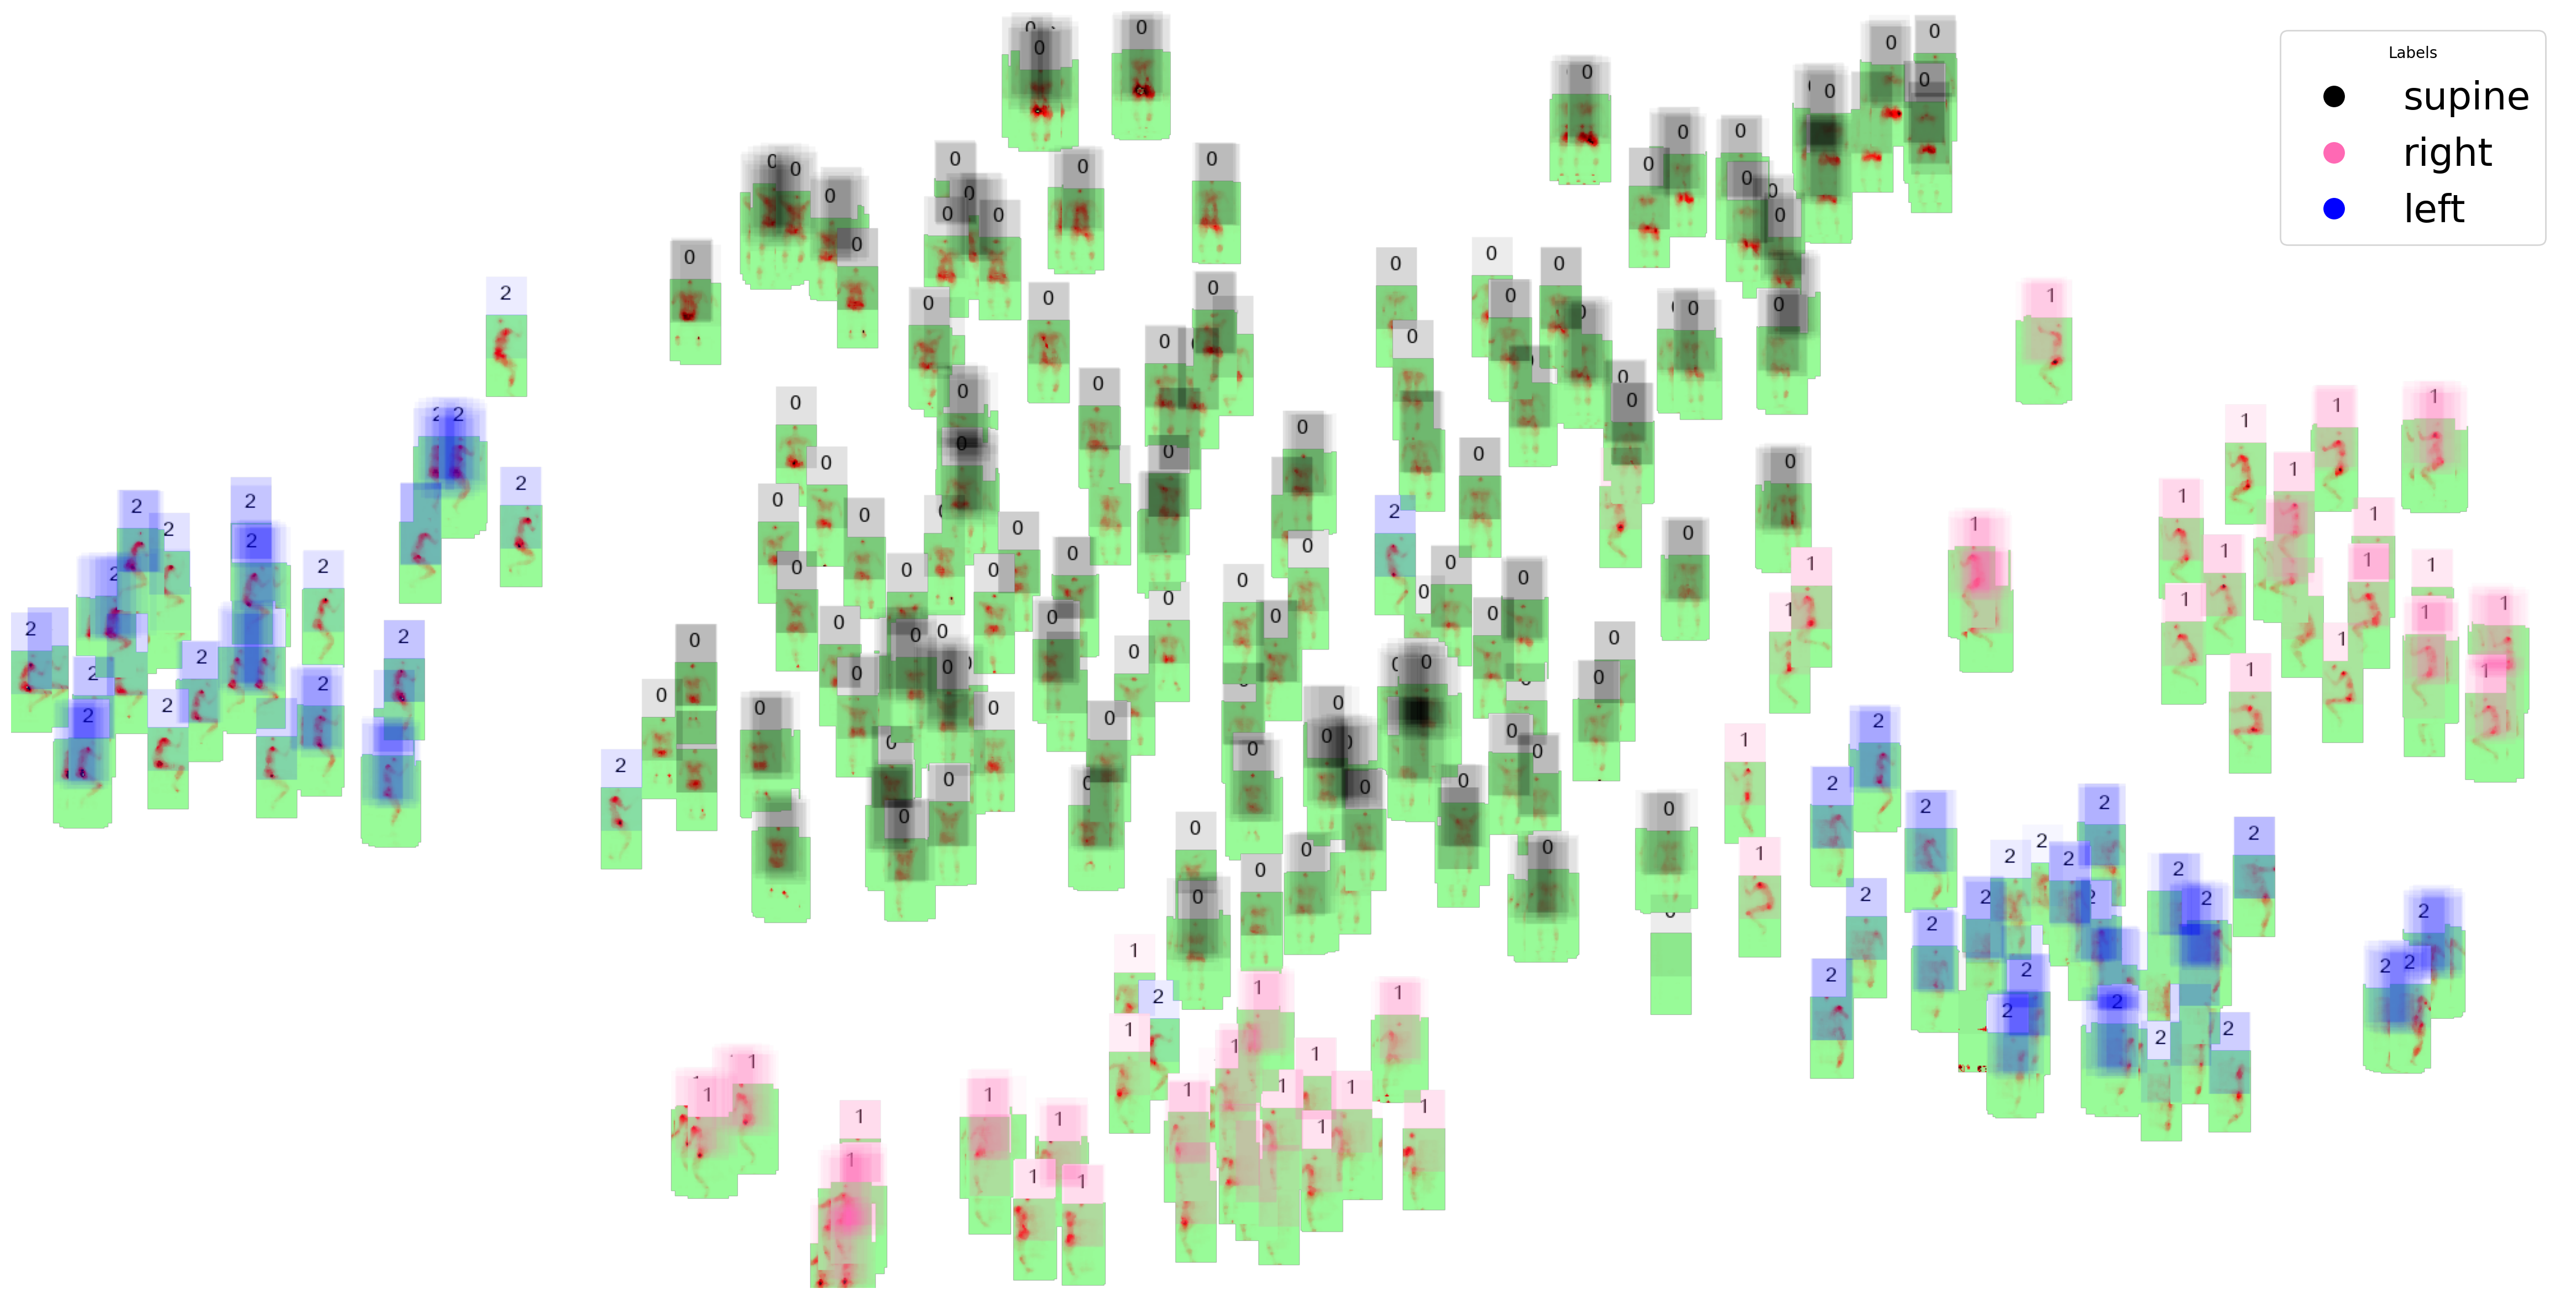

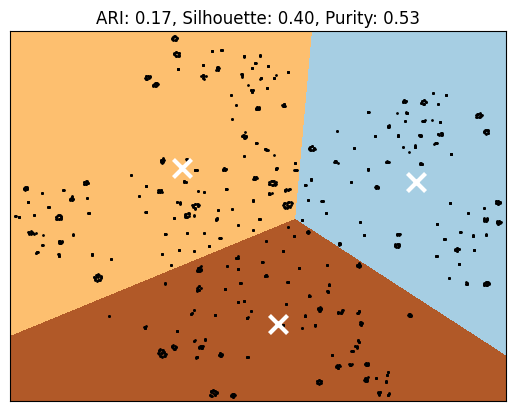

In [97]:
# Plot TSNE and K-means results for raw data
tsne_reduced = tsne_model(X_img.reshape(X_img.shape[0], -1), X_img, y_img)
kmeans_model(tsne_reduced.astype('double'), 3, y_img)

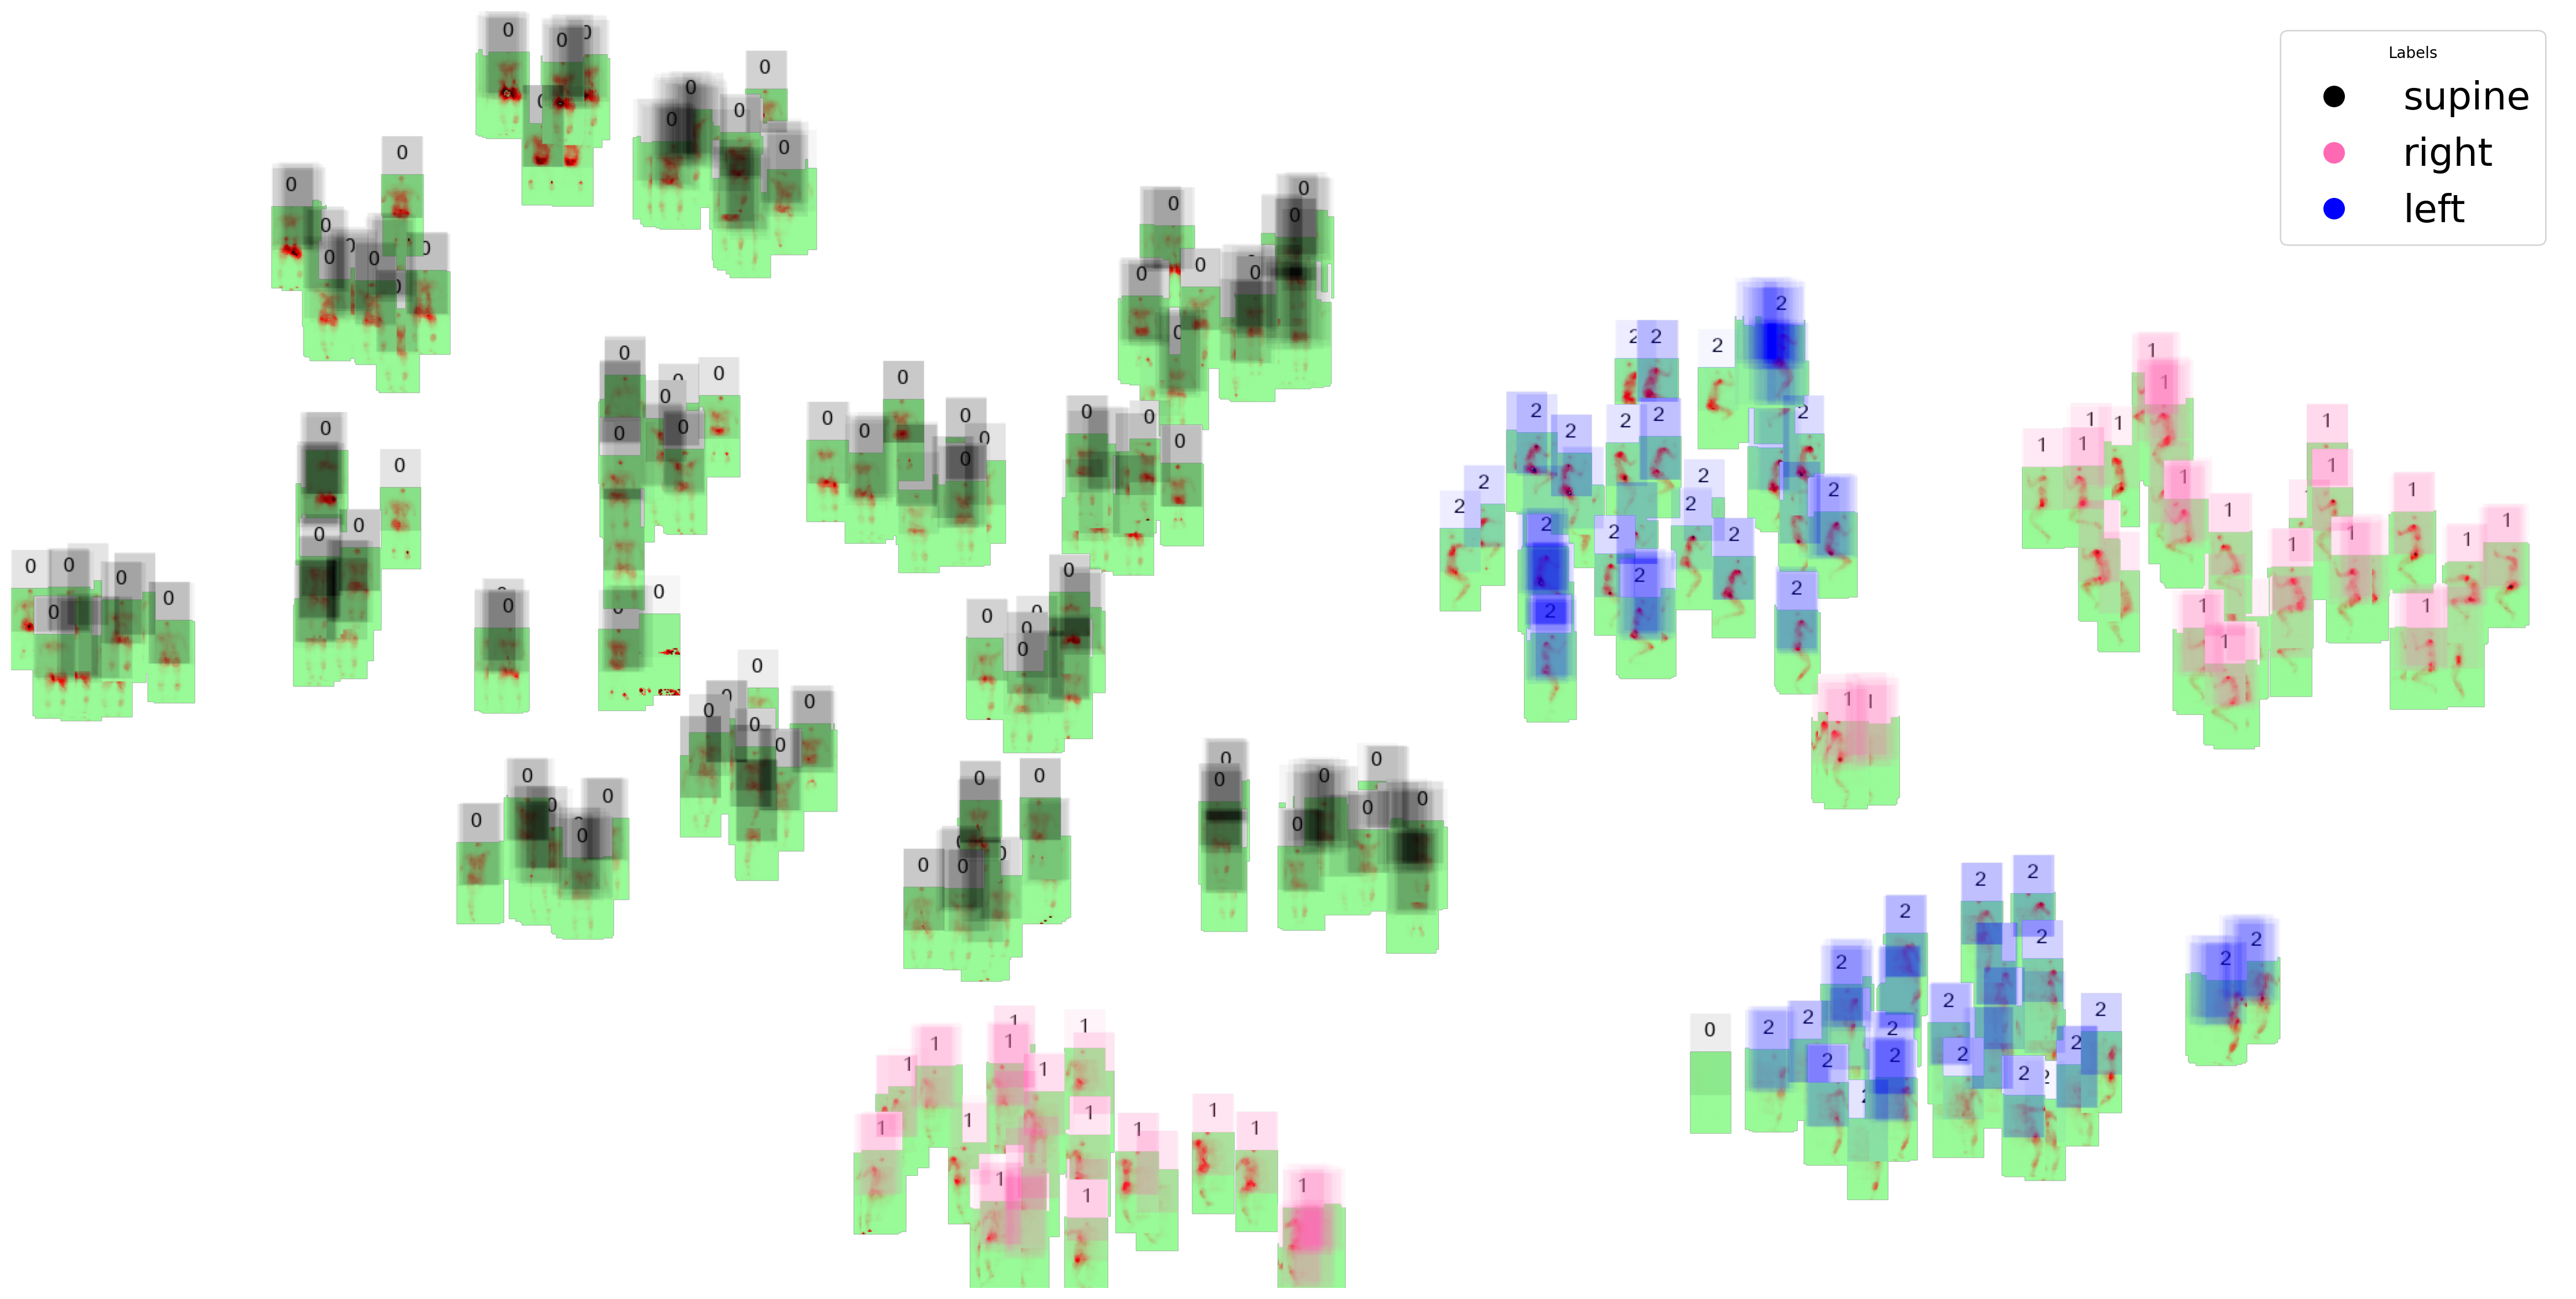

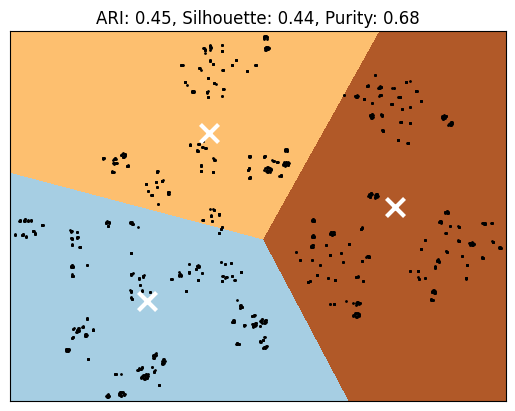

In [98]:
# Plot TSNE and K-means results for encoded data
tsne_encodings_reduced = tsne_model(encodings_sample, X_img, y_img)
kmeans_model(tsne_encodings_reduced.astype('double'), 3, y_img)